# Healthcare Claim Rejection Prediction — LightGBM (No ClaimCategory / Honest Feature Ablation)
### Cameroon openIMIS Relational Database — 13 Joined Tables (Adjudicated Claims)

---

## 🛠️ Fixing the 'Cheating' Model
In previous baseline runs, the `ClaimCategory` field was found to carry **~79% of the model's total gain**. In openIMIS, `ClaimCategory` frequently acts as a post-adjudication classification (recording the administrative disposition of the claim) rather than a genuine pre-submission attribute. Relying on it allowed the model to achieve an artificially inflated PR-AUC (~0.9635) while masking the true predictive power of clinical and policy features.

**Changes in this Notebook:**
1. **Target Leakage Removal**: `ClaimCategory` has been placed on the **Leakage Deny-List (`DENY`)** and completely removed from feature extraction.
2. **Honest Re-Training**: LightGBM is trained strictly on legitimate, pre-submission features across all 13 openIMIS tables.
3. **Re-Evaluating Feature Block Ablation (§17)**: With the dominant 79% field removed, the feature ablation test measures which tables and features (policy validity, service line itemization, facility risk, diagnosis, timing) actually carry genuine predictive signal.


## §0 — Configuration

In [1]:
import os, gc, json, time, warnings, datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             roc_curve, confusion_matrix, classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 80)

CONFIG = {
    "DATA_DIR":  r"../data" if os.path.exists(r"../data/TblClaim.csv") else (r"data" if os.path.exists(r"data/TblClaim.csv") else r"h:\SSD_Backup\Cameroon 2nd Report Codes\data"),
    "MODEL_DIR": r"../model_lightgbm_no_leakage" if os.path.exists(r"../data") else r"model_lightgbm_no_leakage",

    # ---- which tables to load. Set False to skip any that are missing. ----
    "USE_TABLES": {
        "TblClaim": True, "TblClaimServices": True, "TblServices": True,
        "TblInsuree": True, "TblInsureePolicy": True, "TblPolicy": True,
        "TblFamilies": True, "TblHF": True, "TblICDCodes": True,
        "TblLocations": True, "UvwLocations": True,
        "TblClaimItems": True, "TblItems": True,
    },

    # ---- D9 ----------------------------------------------------------------
    "ACCEPTED_STATUSES": (16, 32),
    "REJECTED_STATUSES": (1,),

    # ---- leakage -----------------------------------------------------------
    "USE_POST_ADJUDICATION_FEATURES": False,
    "LEAKAGE_CORR_LIMIT": 0.90,
    "LEAKAGE_AUC_LIMIT":  0.99,     # a single-feature AUC above this = leakage

    # ---- parsing -----------------------------------------------------------
    "MONEY_HAS_DECIMALS": False,
    "MAX_MONEY_UNPARSEABLE_RATE": 0.01,
    "MAX_DATE_NAT_RATE": 0.05,
    "PLAUSIBLE_DATE_MIN": "2015-01-01",   # the AE run found dates from 1995 to 2029
    "PLAUSIBLE_DATE_MAX": "2027-12-31",

    # ---- D14 split ---------------------------------------------------------
    "SPLIT_MODE": "temporal",
    "TRAIN_FRAC": 0.70, "VAL_FRAC": 0.15,

    # ---- LightGBM ----------------------------------------------------------
    "LGB_PARAMS": {
        "objective": "binary", "metric": "average_precision",
        "boosting_type": "gbdt", "learning_rate": 0.05,
        "num_leaves": 63, "max_depth": -1, "min_data_in_leaf": 200,
        "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
        "lambda_l1": 0.0, "lambda_l2": 1.0,
        "max_cat_threshold": 64, "cat_smooth": 20.0, "cat_l2": 10.0,
        "verbosity": -1, "num_threads": 0, "seed": 42,
    },
    "NUM_BOOST_ROUND": 2000,
    "EARLY_STOPPING": 100,

    # ---- imbalance ---------------------------------------------------------
    "IMBALANCE_STRATEGY": None,   # None => decided empirically in §11
    "RUN_SMOTE": True,            # SMOTENC is slow; set False to skip
    "SMOTE_SUBSAMPLE": 300_000,

    "N_SEEDS": 3,
    "SEED": 42,

    # ---- threshold ---------------------------------------------------------
    "THRESHOLD_MODE": "capacity",
    "AUDIT_CAPACITY_PER_DAY": 500,
    "F_BETA": 0.5, "COST_FN": 15000.0, "COST_FP": 2000.0,

    "MIN_FACILITY_CLAIMS": 100,
    "SHAP_SAMPLE": 20_000,

    # ---- runtime -----------------------------------------------------------
    "SAMPLE_FRAC": 1.0,
    "CHUNK_SIZE": 2_000_000,
    "EXPECTED_CLAIM_ROWS": 14_242_741,
}

DATA_DIR  = Path(CONFIG["DATA_DIR"])
MODEL_DIR = Path(CONFIG["MODEL_DIR"]); MODEL_DIR.mkdir(parents=True, exist_ok=True)
F = lambda name: DATA_DIR / f"{name}.csv"

SEED = CONFIG["SEED"]
np.random.seed(SEED)

print(f"pandas {pd.__version__} | numpy {np.__version__} | lightgbm {lgb.__version__}")
print(f"\nPost-adjudication features: "
      f"{'ENABLED (post-payment model)' if CONFIG['USE_POST_ADJUDICATION_FEATURES'] else 'DISABLED (leakage-free)'}")
print(f"Split mode : {CONFIG['SPLIT_MODE']}")
print("\nTables requested:")
for t, on in CONFIG["USE_TABLES"].items():
    exists = F(t).exists()
    size = f"{F(t).stat().st_size/1024**2:,.0f} MB" if exists else "MISSING"
    mark = "on " if on else "off"
    print(f"  [{mark}] {t:<20} {size}")
missing = [t for t, on in CONFIG["USE_TABLES"].items() if on and not F(t).exists()]
if missing:
    print(f"\nWARNING: requested but not found: {missing}")
    print("Set them to False in CONFIG['USE_TABLES'] or fix DATA_DIR.")

pandas 3.0.5 | numpy 2.5.1 | lightgbm 4.7.0

Post-adjudication features: DISABLED (leakage-free)
Split mode : temporal

Tables requested:
  [on ] TblClaim             3,722 MB
  [on ] TblClaimServices     1,771 MB
  [on ] TblServices          5 MB
  [on ] TblInsuree           MISSING
  [on ] TblInsureePolicy     136 MB
  [on ] TblPolicy            MISSING
  [on ] TblFamilies          627 MB
  [on ] TblHF                0 MB
  [on ] TblICDCodes          0 MB
  [on ] TblLocations         2 MB
  [on ] UvwLocations         0 MB
  [on ] TblClaimItems        0 MB
  [on ] TblItems             0 MB

Set them to False in CONFIG['USE_TABLES'] or fix DATA_DIR.


In [2]:
# ---------------------------------------------------------------------------
# Shared helpers -- identical to the other three notebooks in this series.
# ---------------------------------------------------------------------------
_SPACE = r"[\s\u00A0\u202F\u2009\u2007]"

def parse_money(s, has_decimals=None):
    """D2. Currency stored as text with unicode thousands separators ('5 020').
    Returns NaN for unparseable values -- never 0.0, because 0 is a real amount."""
    if has_decimals is None:
        has_decimals = CONFIG["MONEY_HAS_DECIMALS"]
    if pd.api.types.is_numeric_dtype(s):
        return s.astype("float64")
    t = s.astype("string").str.strip()
    t = t.str.replace(_SPACE, "", regex=True).str.replace(r"[^\d\.,\-]", "", regex=True)
    if has_decimals:
        t = t.str.replace(r"[\.,](?=\d{3}(?:\D|$))", "", regex=True).str.replace(",", ".", regex=False)
    else:
        t = t.str.replace(r"[\.,]", "", regex=True)
    return pd.to_numeric(t.replace({"": pd.NA, "-": pd.NA}), errors="coerce").astype("float64")

DATE_FORMATS = ["%d %b, %Y, %H:%M", "%d %b, %Y, %H:%M:%S", "%d %b, %Y",
                "%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d",
                "%d/%m/%Y %H:%M", "%d/%m/%Y", "%m/%d/%Y"]

def parse_dates(s, formats=DATE_FORMATS, plausible=True):
    """D22. Explicit format cascade. Optionally null out impossible dates -- the
    autoencoder run found claim dates spanning 1995 to 2029."""
    if not pd.api.types.is_datetime64_any_dtype(s):
        t = s.astype("string").str.strip()
        out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
        todo = out.isna() & t.notna()
        for fmt in formats:
            if not todo.any():
                break
            out.loc[todo] = pd.to_datetime(t[todo], format=fmt, errors="coerce")
            todo = out.isna() & t.notna()
        if todo.any():
            try:
                out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", format="mixed", dayfirst=True)
            except (TypeError, ValueError):
                out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", dayfirst=True)
    else:
        out = s.copy()
    if plausible:
        lo, hi = pd.Timestamp(CONFIG["PLAUSIBLE_DATE_MIN"]), pd.Timestamp(CONFIG["PLAUSIBLE_DATE_MAX"])
        out = out.where((out >= lo) & (out <= hi))
    return out

def read_cols(name, cols, **kw):
    """Read only the columns that actually exist, as strings, and report."""
    if not F(name).exists() or not CONFIG["USE_TABLES"].get(name, False):
        print(f"  {name}: skipped")
        return None
    head = pd.read_csv(F(name), nrows=0)
    have = [c for c in cols if c in head.columns]
    miss = [c for c in cols if c not in head.columns]
    df_ = pd.read_csv(F(name), usecols=have, dtype=str, low_memory=False, **kw)
    print(f"  {name}: {len(df_):,} rows, {len(have)} cols" + (f"  (missing: {miss})" if miss else ""))
    return df_

def assert_rows(df_, expected, label):
    if expected is not None and len(df_) != expected:
        raise AssertionError(f"[{label}] rows {len(df_):,} != {expected:,} -- a merge key is non-unique")
    print(f"  [ok] {label}: {len(df_):,} rows")

def dedupe_key(df_, key, label):
    n0 = len(df_)
    df_ = df_.dropna(subset=[key]).drop_duplicates(subset=[key], keep="last")
    if n0 != len(df_):
        print(f"  {label}: {n0:,} -> {len(df_):,} unique on {key} "
              f"({n0-len(df_):,} duplicate/SCD rows collapsed)")
    return df_

print("Helpers loaded: parse_money, parse_dates, read_cols, assert_rows, dedupe_key")

Helpers loaded: parse_money, parse_dates, read_cols, assert_rows, dedupe_key


## §1 — Pre-flight gate

Same discipline as the other notebooks, extended across all thirteen tables: check the raw
dtypes, confirm money and dates parse, and — new here — **measure join-key coverage**, because
a join that silently matches 3% of rows produces a feature that is 97% missing and looks fine
in a summary table.

In [3]:
PREFLIGHT_N = 200_000
print("=" * 78); print("PRE-FLIGHT"); print("=" * 78)

pf = pd.read_csv(F("TblClaim"), nrows=PREFLIGHT_N, dtype=str)
print(f"\n[1] TblClaim: {len(pf.columns)} columns, first {PREFLIGHT_N:,} rows")

print("\n[2] MONEY PARSING")
money_fail = {}
for col in ["Claimed", "Approved"]:
    if col in pf.columns:
        raw = pf[col]; naive = pd.to_numeric(raw, errors="coerce"); fixed = parse_money(raw)
        present = raw.notna()
        nb = (present & naive.isna()).sum()/max(present.sum(),1)
        fb = (present & fixed.isna()).sum()/max(present.sum(),1)
        money_fail[col] = fb
        print(f"  {col:<10} naive-unparseable {nb:7.2%} -> parse_money {fb:7.2%} | "
              f"mean {naive.fillna(0).mean():,.0f} -> {fixed.mean():,.0f}")

print("\n[3] DATE PARSING & PLAUSIBILITY")
date_fail = {}
for col in ["DateFrom", "DateTo", "DateClaimed"]:
    if col in pf.columns:
        present = pf[col].notna()
        loose = parse_dates(pf[col], plausible=False)
        strict = parse_dates(pf[col], plausible=True)
        fb = (present & loose.isna()).sum()/max(present.sum(),1)
        implausible = (loose.notna() & strict.isna()).mean()
        date_fail[col] = fb
        print(f"  {col:<12} unparseable {fb:6.2%} | implausible (outside "
              f"{CONFIG['PLAUSIBLE_DATE_MIN']}..{CONFIG['PLAUSIBLE_DATE_MAX']}) {implausible:6.2%} "
              f"| range {loose.min()} .. {loose.max()}")

print("\n[4] CLAIM STATUS (D9)")
vc = pd.to_numeric(pf["ClaimStatus"], errors="coerce").value_counts()
names = {1:"REJECTED",2:"ENTERED",4:"CHECKED",8:"PROCESSED",16:"VALUATED",32:"PAYMENT"}
keep = set(CONFIG["ACCEPTED_STATUSES"]) | set(CONFIG["REJECTED_STATUSES"])
for st, n in vc.items():
    print(f"  {str(st):>4} {names.get(st,'?'):<10} {n:>9,} {n/len(pf):7.2%}  "
          f"{'keep' if st in keep else 'DROP (in-flight)'}")

print("\n[5] JOIN-KEY COVERAGE  (a join matching a few percent of rows is worse than no join)")
checks = [("Hfid","TblHF","HfID"), ("Icdid","TblICDCodes","Icdid"),
          ("InsureeID","TblInsuree","InsureeID"), ("ClaimID","TblClaimServices","ClaimID")]
for left, tbl, right in checks:
    if left not in pf.columns or not F(tbl).exists() or not CONFIG["USE_TABLES"].get(tbl, False):
        print(f"  {left:<12} -> {tbl:<18} skipped"); continue
    head = pd.read_csv(F(tbl), nrows=0)
    rc = right if right in head.columns else next(
        (c for c in head.columns if c.lower() == right.lower()), None)
    if rc is None:
        print(f"  {left:<12} -> {tbl:<18} key '{right}' not found; columns: {list(head.columns)[:6]}")
        continue
    keys = pd.read_csv(F(tbl), usecols=[rc], dtype=str).iloc[:, 0].dropna().unique()
    cov = pf[left].isin(set(keys)).mean()
    flag = "" if cov > 0.95 else ("   <-- LOW, investigate" if cov < 0.5 else "   <-- partial")
    print(f"  {left:<12} -> {tbl:<18} {cov:7.2%} of claims match{flag}")

problems = ([f"{c}: {r:.2%} money unparseable" for c, r in money_fail.items()
             if r > CONFIG["MAX_MONEY_UNPARSEABLE_RATE"]] +
            [f"{c}: {r:.2%} dates unparseable" for c, r in date_fail.items()
             if r > CONFIG["MAX_DATE_NAT_RATE"]])
print("\n" + "=" * 78)
if problems:
    print("PRE-FLIGHT FAILED"); [print("  - " + p) for p in problems]
    raise AssertionError("Fix the parser configuration before continuing.")
print("PRE-FLIGHT PASSED"); print("=" * 78)
del pf; gc.collect()

PRE-FLIGHT

[1] TblClaim: 56 columns, first 200,000 rows

[2] MONEY PARSING
  Claimed    naive-unparseable  68.69% -> parse_money   0.00% | mean 160 -> 6,212
  Approved   naive-unparseable  69.27% -> parse_money   0.00% | mean 114 -> 4,306

[3] DATE PARSING & PLAUSIBILITY
  DateFrom     unparseable  0.00% | implausible (outside 2015-01-01..2027-12-31)  0.00% | range 2025-04-01 00:00:00 .. 2025-04-30 00:00:00
  DateTo       unparseable  0.00% | implausible (outside 2015-01-01..2027-12-31)  0.00% | range 2025-04-01 00:00:00 .. 2026-05-14 00:00:00
  DateClaimed  unparseable  0.00% | implausible (outside 2015-01-01..2027-12-31)  0.00% | range 2025-04-01 00:00:00 .. 2028-09-12 00:00:00

[4] CLAIM STATUS (D9)
    16 VALUATED      85,441  42.72%  keep
     4 CHECKED       54,121  27.06%  DROP (in-flight)
     2 ENTERED       42,484  21.24%  DROP (in-flight)
     1 REJECTED      11,414   5.71%  keep
     8 PROCESSED      6,139   3.07%  DROP (in-flight)
    32 PAYMENT          401   0.20%  keep

20

## §2 — Dimension tables

Small reference tables, loaded once and deduplicated on their key. `dedupe_key` guards against
the SCD Type 2 fan-out risk: several of these are versioned tables where one entity can appear
multiple times, and an un-guarded merge would silently duplicate claim rows.

In [4]:
print("Loading dimension tables...")
DIM = {}

# --- facilities, with geography attached ---------------------------------
hf = read_cols("TblHF", ["HfID","HFLevel","HFCareType","LegalForm","LocationId","Sublevel"])
if hf is not None:
    hf["HfID"] = pd.to_numeric(hf["HfID"], errors="coerce")
    hf = dedupe_key(hf, "HfID", "TblHF")
    hf["HfID"] = hf["HfID"].astype("int64")
    for c in [c for c in ["HFLevel","HFCareType","LegalForm","Sublevel"] if c in hf]:
        hf[c] = hf[c].fillna("UNK").str.strip().str.upper()
        print(f"    HF.{c:<12} {sorted(hf[c].unique())[:8]}")
DIM["hf"] = hf

# --- geography: prefer the flattened view, fall back to the hierarchy ------
loc = read_cols("UvwLocations", ["LocationId","RegionName","DistrictName","VillageName"])
if loc is None:
    loc = read_cols("TblLocations", ["LocationId","LocationName","LocationType","ParentLocationId"])
    if loc is not None:
        loc = loc.rename(columns={"LocationName":"DistrictName"})
if loc is not None:
    loc["LocationId"] = pd.to_numeric(loc["LocationId"], errors="coerce")
    loc = dedupe_key(loc, "LocationId", "locations")
    loc["LocationId"] = loc["LocationId"].astype("int64")
DIM["loc"] = loc

# --- diagnosis catalogue: group 2,203 codes into ICD-10 chapters -----------
icd = read_cols("TblICDCodes", ["Icdid","ICDCode","ICDName"])
if icd is not None:
    icd["Icdid"] = pd.to_numeric(icd["Icdid"], errors="coerce")
    icd = dedupe_key(icd, "Icdid", "TblICDCodes")
    icd["Icdid"] = icd["Icdid"].astype("int64")
    # ICD-10 chapter = leading letter; far more generalisable than a 2,203-level ID
    icd["ICD_Chapter"] = icd["ICDCode"].astype(str).str.strip().str[0].str.upper()
    icd.loc[~icd["ICD_Chapter"].str.match(r"^[A-Z]$", na=False), "ICD_Chapter"] = "UNK"
    print(f"    ICD chapters: {sorted(icd['ICD_Chapter'].unique())}")
DIM["icd"] = icd

# --- service catalogue: the tariff baseline, i.e. the upcoding reference ---
svc = read_cols("TblServices", ["ServiceID","ServPrice","ServFrequency","ServType",
                                "ServLevel","ServCareType","ServCategory","ServPatCat",
                                "ServPackageType","ManualPrice"])
if svc is not None:
    svc["ServiceID"] = pd.to_numeric(svc["ServiceID"], errors="coerce")
    svc = dedupe_key(svc, "ServiceID", "TblServices")
    svc["ServiceID"] = svc["ServiceID"].astype("int64")
    svc["ServPrice"]     = parse_money(svc["ServPrice"])
    svc["ServFrequency"] = pd.to_numeric(svc["ServFrequency"], errors="coerce")
    svc["ServPatCat"]    = pd.to_numeric(svc["ServPatCat"], errors="coerce")
    print(f"    tariff ServPrice: median {svc['ServPrice'].median():,.0f} XAF, "
          f"n={svc['ServPrice'].notna().sum():,}")
DIM["svc"] = svc

# --- item catalogue (tiny) -------------------------------------------------
itm = read_cols("TblItems", ["ItemID","ItemPrice","ItemType","ItemCareType"])
if itm is not None:
    itm["ItemID"] = pd.to_numeric(itm["ItemID"], errors="coerce")
    itm = dedupe_key(itm, "ItemID", "TblItems")
    itm["ItemID"] = itm["ItemID"].astype("int64")
    itm["ItemPrice"] = parse_money(itm["ItemPrice"])
DIM["itm"] = itm

print("\nDimension tables ready.")

Loading dimension tables...
  TblHF: 2,512 rows, 5 cols  (missing: ['Sublevel'])
    HF.HFLevel      ['C', 'D', 'H']
    HF.HFCareType   ['B', 'I', 'O']
    HF.LegalForm    ['C', 'D', 'G', 'P']
  UvwLocations: 4,136 rows, 4 cols
  locations: 4,136 -> 911 unique on LocationId (3,225 duplicate/SCD rows collapsed)
  TblICDCodes: 2,203 rows, 3 cols
    ICD chapters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'UNK', 'V', 'W', 'X', 'Y', 'Z']
  TblServices: 27,832 rows, 10 cols
    tariff ServPrice: median 1,000 XAF, n=27,832
  TblItems: 176 rows, 4 cols

Dimension tables ready.


## §3 — Service line items: basket composition and the tariff-breach signal

This is where the highest-value features in the whole notebook come from. Joining
`TblClaimServices` to the `TblServices` catalogue gives, for every line on every claim, the
price the facility **asked** against the price the catalogue **says** — and their ratio is the
most direct upcoding signal in the dataset. The data quality report already counted 412,890
line items where that ratio exceeds 1.5, and no previous notebook used it.

**Leakage note.** `TblClaimServices` carries eight fields written during adjudication:
`QtyApproved`, `PriceApproved`, `PriceValuated`, `PriceAdjusted`, `RemuneratedAmount`,
`DeductableAmount`, `ExceedCeilingAmount`, `RejectionReason`, `ClaimServiceStatus`. None is
read here. `PriceAdjusted` is excluded too — its sample values match `PriceAsked`, but it is
populated by the adjudicator, so it cannot be trusted as pre-submission data.

In [5]:
t0 = time.time()
cs = read_cols("TblClaimServices", ["ClaimID","ServiceID","QtyProvided","PriceAsked",
                                    "PriceOrigin","LimitationValue"])
if cs is not None:
    cs["ClaimID"]     = pd.to_numeric(cs["ClaimID"], errors="coerce")
    cs["ServiceID"]   = pd.to_numeric(cs["ServiceID"], errors="coerce")
    cs["QtyProvided"] = pd.to_numeric(cs["QtyProvided"], errors="coerce")
    cs["PriceAsked"]  = parse_money(cs["PriceAsked"])
    cs = cs.dropna(subset=["ClaimID"])

    print(f"  PriceAsked unparseable: {cs['PriceAsked'].isna().mean():.3%}")
    print(f"  PriceAsked median / p99 / max: {cs['PriceAsked'].median():,.0f} / "
          f"{cs['PriceAsked'].quantile(0.99):,.0f} / {cs['PriceAsked'].max():,.0f}")
    if cs["PriceAsked"].max() > 1e9:
        print("  WARNING: a line-item price exceeds 1 billion XAF. The autoencoder run hit the")
        print("           same value (700,070,007,000). Either MONEY_HAS_DECIMALS is wrong or")
        print("           the source contains corrupt rows. Extreme values are winsorised below,")
        print("           but the root cause should be investigated.")

    # --- tariff comparison: the upcoding signal ---------------------------
    if DIM["svc"] is not None:
        n0 = len(cs)
        cs = cs.merge(DIM["svc"][["ServiceID","ServPrice","ServFrequency","ServType",
                                  "ServLevel","ServCategory","ServPatCat"]],
                      on="ServiceID", how="left")
        assert len(cs) == n0, "TblServices merge fanned out line items"
        cs["line_total"]    = cs["PriceAsked"] * cs["QtyProvided"].fillna(1)
        cs["tariff_ratio"]  = np.where(cs["ServPrice"] > 0, cs["PriceAsked"] / cs["ServPrice"], np.nan)
        cs["tariff_breach"] = (cs["tariff_ratio"] > 1.5).astype("float64")
        matched = cs["ServPrice"].notna().mean()
        print(f"  catalogue match: {matched:.2%} of line items")
        print(f"  tariff_ratio median {cs['tariff_ratio'].median():.3f} | "
              f"breaches (>1.5x): {int(cs['tariff_breach'].sum()):,} "
              f"({cs['tariff_breach'].mean():.2%})")
    else:
        cs["line_total"] = cs["PriceAsked"] * cs["QtyProvided"].fillna(1)
        for c in ["tariff_ratio","tariff_breach","ServPrice","ServFrequency","ServPatCat"]:
            cs[c] = np.nan
        cs["ServType"] = cs["ServLevel"] = cs["ServCategory"] = None

    # --- aggregate to one row per claim -----------------------------------
    g = cs.groupby("ClaimID")
    srv = pd.DataFrame({
        "SVC_n_lines":        g.size(),
        "SVC_n_distinct":     g["ServiceID"].nunique(),
        "SVC_qty_total":      g["QtyProvided"].sum(min_count=1),
        "SVC_qty_max":        g["QtyProvided"].max(),
        "SVC_asked_total":    g["line_total"].sum(min_count=1),
        "SVC_asked_max":      g["PriceAsked"].max(),
        "SVC_asked_mean":     g["PriceAsked"].mean(),
        "SVC_tariff_total":   g["ServPrice"].sum(min_count=1),
        "SVC_tariff_ratio_max":  g["tariff_ratio"].max(),
        "SVC_tariff_ratio_mean": g["tariff_ratio"].mean(),
        "SVC_tariff_breaches":   g["tariff_breach"].sum(min_count=1),
        "SVC_freq_limit_min":    g["ServFrequency"].min(),
        "SVC_patcat_nunique":    g["ServPatCat"].nunique(),
    }).reset_index()
    # basket concentration: is one line carrying the whole bill?
    srv["SVC_repeat_rate"] = 1 - srv["SVC_n_distinct"] / srv["SVC_n_lines"].clip(lower=1)
    srv["SVC_top_line_share"] = srv["SVC_asked_max"] / srv["SVC_asked_total"].replace(0, np.nan)
    assert srv["ClaimID"].is_unique
    print(f"  aggregated to {len(srv):,} claims in {time.time()-t0:.0f}s")
    del cs, g; gc.collect()
else:
    srv = None

# --- item lines (near-empty, carried honestly as a flag) -------------------
ci = read_cols("TblClaimItems", ["ClaimID","ItemID","QtyProvided","PriceAsked"])
if ci is not None and len(ci):
    ci["ClaimID"] = pd.to_numeric(ci["ClaimID"], errors="coerce")
    ci["PriceAsked"] = parse_money(ci["PriceAsked"])
    itms = ci.groupby("ClaimID").agg(ITM_n_lines=("ItemID","size"),
                                     ITM_asked_total=("PriceAsked","sum")).reset_index()
    print(f"  TblClaimItems covers {len(itms):,} claims "
          f"({len(itms)/CONFIG['EXPECTED_CLAIM_ROWS']:.4%} of the ledger) -- "
          "effectively empty, carried as a flag only")
    del ci; gc.collect()
else:
    itms = None

  TblClaimServices: 15,774,762 rows, 6 cols
  PriceAsked unparseable: 0.000%
  PriceAsked median / p99 / max: 2,500 / 22,900 / 700,070,007,000
           same value (700,070,007,000). Either MONEY_HAS_DECIMALS is wrong or
           the source contains corrupt rows. Extreme values are winsorised below,
           but the root cause should be investigated.
  catalogue match: 100.00% of line items
  tariff_ratio median 1.000 | breaches (>1.5x): 80,267 (0.51%)
  aggregated to 14,547,637 claims in 101s
  TblClaimItems: 1,728 rows, 4 cols
  TblClaimItems covers 383 claims (0.0027% of the ledger) -- effectively empty, carried as a flag only


## §4 — Claim headers

Only fully adjudicated claims are kept (D9). Claims still in flight have no final decision, so
treating them as "accepted" contaminates the negative class — the autoencoder run showed 80% of
the ledger sitting in that state.

Nothing is clipped to zero (D13). Negative lengths of stay, backdated submissions and negative
amounts are kept with their sign and given explicit flags, because those are the exact
conditions worth detecting.

In [6]:
CLAIM_COLS = ["ClaimID","ClaimStatus","RejectionReason","Claimed","DateFrom","DateTo",
              "DateClaimed","Hfid","Icdid","InsureeID","CareType","VisitType",
              "ClaimCategory","HealthFacilityID","Explanation","GuaranteeId"]
if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
    CLAIM_COLS += ["Approved"]

head = pd.read_csv(F("TblClaim"), nrows=0)
CLAIM_COLS = [c for c in CLAIM_COLS if c in head.columns]

ACCEPTED = set(CONFIG["ACCEPTED_STATUSES"]); REJECTED = set(CONFIG["REJECTED_STATUSES"])
KEEP = ACCEPTED | REJECTED
chunks, n_raw, n_inflight, n_baddate = [], 0, 0, 0
rng_s = np.random.default_rng(SEED)

print("Ingesting TblClaim.csv ...")
for i, ch in enumerate(pd.read_csv(F("TblClaim"), usecols=CLAIM_COLS, dtype=str,
                                   chunksize=CONFIG["CHUNK_SIZE"], low_memory=False)):
    n_raw += len(ch)
    if CONFIG["SAMPLE_FRAC"] < 1.0:
        ch = ch.loc[rng_s.random(len(ch)) < CONFIG["SAMPLE_FRAC"]].copy()

    ch["ClaimStatus"] = pd.to_numeric(ch["ClaimStatus"], errors="coerce")
    before = len(ch)
    ch = ch[ch["ClaimStatus"].isin(KEEP)].copy()
    n_inflight += before - len(ch)
    if ch.empty:
        continue

    ch["y"] = ch["ClaimStatus"].isin(REJECTED).astype("int8")
    ch["RejectionCode"] = (ch["RejectionReason"].fillna("0").astype(str).str.strip()
                             .str.replace(r"\.0$", "", regex=True))
    for c in ["ClaimID","Hfid","Icdid","InsureeID"]:
        if c in ch:
            ch[c] = pd.to_numeric(ch[c], errors="coerce")

    claimed = parse_money(ch["Claimed"])
    ch["CLM_claimed"]   = claimed
    ch["ISNA_claimed"]  = claimed.isna().astype("int8")
    ch["FLAG_neg_claimed"] = (claimed < 0).fillna(False).astype("int8")

    d_from = parse_dates(ch["DateFrom"]); d_to = parse_dates(ch["DateTo"])
    d_clm  = parse_dates(ch["DateClaimed"])
    before = len(ch)
    ch = ch[d_clm.notna() & d_from.notna()].copy()
    d_from, d_to, d_clm = d_from[ch.index], d_to[ch.index], d_clm[ch.index]
    n_baddate += before - len(ch)

    ch["DateFrom_p"], ch["DateTo_p"], ch["DateClaimed_p"] = d_from, d_to, d_clm
    los   = (d_to - d_from).dt.days
    delay = (d_clm - d_to).dt.days
    ch["CLM_los"]   = los
    ch["CLM_delay"] = delay
    ch["FLAG_negative_los"] = (los < 0).fillna(False).astype("int8")
    ch["FLAG_backdated"]    = (delay < 0).fillna(False).astype("int8")
    ch["FLAG_los_over_year"]= (los > 365).fillna(False).astype("int8")
    ch["CLM_month"]   = d_from.dt.month
    ch["CLM_dayofweek"] = d_from.dt.dayofweek
    ch["FLAG_weekend"] = (d_from.dt.dayofweek >= 5).astype("int8")
    ch["FLAG_round_amount"] = ((claimed % 1000 == 0) & (claimed > 0)).fillna(False).astype("int8")

    for c in ["CareType","VisitType"]:
        if c in ch:
            ch[c] = ch[c].fillna("UNK").astype(str).str.strip().str.upper().replace({"": "UNK"})
        else:
            ch[c] = "UNK"
    ch["FLAG_has_explanation"] = ch["Explanation"].notna().astype("int8") if "Explanation" in ch else 0
    ch["FLAG_has_guarantee"]   = ch["GuaranteeId"].notna().astype("int8") if "GuaranteeId" in ch else 0

    if CONFIG["USE_POST_ADJUDICATION_FEATURES"] and "Approved" in ch:
        appr = parse_money(ch["Approved"])
        ch["POST_approved"] = appr
        ch["POST_deduction"] = claimed - appr
        ch["POST_approval_ratio"] = np.where(claimed.notna() & (claimed != 0), appr/claimed, np.nan)

    keepc = (["ClaimID","y","RejectionCode","Hfid","Icdid","InsureeID",
              "DateFrom_p","DateTo_p","DateClaimed_p","CareType","VisitType"]
             + [c for c in ch.columns if c.startswith(("CLM_","FLAG_","ISNA_","POST_"))])
    chunks.append(ch[[c for c in keepc if c in ch.columns]].copy())
    print(f"  chunk {i+1}: kept {len(ch):,}")
    del ch; gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

print(f"\nRaw claim headers      : {n_raw:,}")
print(f"Dropped as in-flight   : {n_inflight:,}  (D9)")
print(f"Dropped, bad/implausible dates : {n_baddate:,}")
print(f"Retained               : {len(df):,}")
print(f"Rejection rate         : {df['y'].mean():.4%}")
print(f"Date range             : {df['DateFrom_p'].min().date()} .. {df['DateFrom_p'].max().date()}")

if srv is not None:
    n0 = len(df); df = df.merge(srv, on="ClaimID", how="left"); assert_rows(df, n0, "merge srv")
    df["FLAG_no_service_lines"] = df["SVC_n_lines"].isna().astype("int8")
    print(f"  claims with no service lines: {df['FLAG_no_service_lines'].mean():.2%}")
if itms is not None:
    n0 = len(df); df = df.merge(itms, on="ClaimID", how="left"); assert_rows(df, n0, "merge items")
    df["FLAG_has_item_lines"] = df["ITM_n_lines"].notna().astype("int8")

# derived ratios -- relative features beat absolute ones
df["CLM_cost_per_day"]     = df["CLM_claimed"] / df["CLM_los"].abs().clip(lower=1)
df["CLM_cost_per_line"]    = df["CLM_claimed"] / df["SVC_n_lines"].clip(lower=1) if "SVC_n_lines" in df else np.nan
df["CLM_header_line_gap"]  = df["CLM_claimed"] - df["SVC_asked_total"] if "SVC_asked_total" in df else np.nan
df["CLM_vs_tariff_total"]  = df["CLM_claimed"] / df["SVC_tariff_total"].replace(0, np.nan) if "SVC_tariff_total" in df else np.nan
del srv, itms; gc.collect()

Ingesting TblClaim.csv ...
  chunk 1: kept 415,083
  chunk 2: kept 356,849
  chunk 3: kept 430,287
  chunk 4: kept 345,238
  chunk 5: kept 438,071
  chunk 6: kept 378,463
  chunk 7: kept 351,732
  chunk 8: kept 69,698

Raw claim headers      : 14,242,741
Dropped as in-flight   : 11,457,317  (D9)
Dropped, bad/implausible dates : 3
Retained               : 2,785,421
Rejection rate         : 15.8156%
Date range             : 2020-01-01 .. 2025-11-30
  [ok] merge srv: 2,785,421 rows
  claims with no service lines: 11.15%
  [ok] merge items: 2,785,421 rows


0

## §5 — Patient, family and policy: a point-in-time join

The single most valuable addition in this notebook, and the easiest to get wrong.

A patient holds several policies over time. Joining "the patient's policy" naively picks an
arbitrary row — usually the newest, which may not have existed when the claim was filed. That
leaks the future into the past and inflates every metric downstream.

`pd.merge_asof` does it correctly: for each claim, take the policy whose `StartDate` is the
**latest one at or before the service date**, and nothing after. This is the standard as-of
join from credit-risk modelling and it is routinely skipped in healthcare ML.

What it unlocks: `days_since_policy_start` and `days_to_policy_expiry`. Rejection codes 3
(expired policy) and 7 (invalid ID) account for roughly 38% of all rejections, and until now
nothing in the feature set could see them. Claiming immediately after enrolment is also one of
the oldest signals in insurance — adverse selection — and it becomes visible here too.

In [7]:
# ---- patient demographics -------------------------------------------------
ins = read_cols("TblInsuree", ["InsureeID","Dob","Gender","IsHead","FamilyID",
                               "Vulnerability","CardIssued","Marital"])
if ins is not None:
    ins["InsureeID"] = pd.to_numeric(ins["InsureeID"], errors="coerce")
    ins = dedupe_key(ins, "InsureeID", "TblInsuree")
    ins["InsureeID"] = ins["InsureeID"].astype("int64")
    ins["Dob_p"]     = parse_dates(ins["Dob"], plausible=False)
    ins["FamilyID"]  = pd.to_numeric(ins["FamilyID"], errors="coerce")
    for c in ["Gender","Marital"]:
        if c in ins:
            ins[c] = ins[c].fillna("UNK").astype(str).str.strip().str.upper().replace({"":"UNK"})
    for c in ["IsHead","Vulnerability","CardIssued"]:
        if c in ins:
            ins[c] = ins[c].astype(str).str.lower().isin(["true","1","t","yes"]).astype("int8")
    ins = ins.rename(columns={"Gender":"PT_gender","Marital":"PT_marital","IsHead":"PT_is_head",
                              "Vulnerability":"PT_vulnerable","CardIssued":"PT_card_issued"})
    n0 = len(df)
    df = df.merge(ins[["InsureeID","Dob_p","FamilyID","PT_gender","PT_marital",
                       "PT_is_head","PT_vulnerable","PT_card_issued"]],
                  on="InsureeID", how="left")
    assert_rows(df, n0, "merge TblInsuree")
    df["PT_age"] = (df["DateFrom_p"] - df["Dob_p"]).dt.days / 365.25
    df.loc[(df["PT_age"] < 0) | (df["PT_age"] > 120), "PT_age"] = np.nan
    df["FLAG_age_missing"] = df["PT_age"].isna().astype("int8")
    print(f"  patient matched: {df['Dob_p'].notna().mean():.2%} | "
          f"median age {df['PT_age'].median():.0f}")
    del ins; gc.collect()

# ---- household ------------------------------------------------------------
fam = read_cols("TblFamilies", ["FamilyID","Poverty","FamilyType","LocationId"])
if fam is not None and "FamilyID" in df.columns:
    fam["FamilyID"] = pd.to_numeric(fam["FamilyID"], errors="coerce")
    fam = dedupe_key(fam, "FamilyID", "TblFamilies")
    fam["FamilyID"] = fam["FamilyID"].astype("int64")
    fam["FAM_poverty"] = fam["Poverty"].astype(str).str.lower().isin(["true","1","t"]).astype("int8")
    fam["FAM_type"] = fam["FamilyType"].fillna("UNK").astype(str).str.strip().str.upper()
    fam["FAM_LocationId"] = pd.to_numeric(fam["LocationId"], errors="coerce")
    n0 = len(df)
    df = df.merge(fam[["FamilyID","FAM_poverty","FAM_type","FAM_LocationId"]],
                  on="FamilyID", how="left")
    assert_rows(df, n0, "merge TblFamilies")
    print(f"  household matched: {df['FAM_type'].notna().mean():.2%}")
    del fam; gc.collect()

# ---- policy: AS-OF join on the service date -------------------------------
ip = read_cols("TblInsureePolicy", ["InsureeID","PolicyId","EnrollmentDate","StartDate",
                                    "EffectiveDate","ExpiryDate"])
pol = read_cols("TblPolicy", ["PolicyID","PolicyStage","PolicyValue","ProdID","OfficerID",
                              "EnrollDate","StartDate","ExpiryDate"])

if ip is not None:
    ip["InsureeID"] = pd.to_numeric(ip["InsureeID"], errors="coerce")
    ip["PolicyId"]  = pd.to_numeric(ip["PolicyId"], errors="coerce")
    for c in ["EnrollmentDate","StartDate","EffectiveDate","ExpiryDate"]:
        if c in ip:
            ip[c + "_p"] = parse_dates(ip[c], plausible=False)
    ip = ip.dropna(subset=["InsureeID","StartDate_p"])

    if pol is not None:
        pol["PolicyID"] = pd.to_numeric(pol["PolicyID"], errors="coerce")
        pol = dedupe_key(pol, "PolicyID", "TblPolicy")
        pol["PolicyID"] = pol["PolicyID"].astype("int64")
        pol["POL_value"] = parse_money(pol["PolicyValue"])
        pol["POL_stage"] = pol["PolicyStage"].fillna("UNK").astype(str).str.strip().str.upper()
        pol["POL_prod"]  = pd.to_numeric(pol["ProdID"], errors="coerce")
        pol["POL_officer"] = pd.to_numeric(pol["OfficerID"], errors="coerce")
        n0 = len(ip)
        ip = ip.merge(pol[["PolicyID","POL_value","POL_stage","POL_prod","POL_officer"]],
                      left_on="PolicyId", right_on="PolicyID", how="left")
        assert len(ip) == n0, "TblPolicy merge fanned out policy rows"
        # NOTE: PolicyStatus is deliberately NOT used. It is the policy's CURRENT status,
        # which may have changed after the claim was filed -- a classic point-in-time leak.
        del pol; gc.collect()

    left  = df[["ClaimID","InsureeID","DateFrom_p"]].dropna(subset=["InsureeID"]).copy()
    left["InsureeID"] = left["InsureeID"].astype("int64")
    left = left.sort_values("DateFrom_p", kind="stable")
    right = ip.sort_values("StartDate_p", kind="stable").copy()
    right["InsureeID"] = right["InsureeID"].astype("int64")

    asof = pd.merge_asof(left, right, left_on="DateFrom_p", right_on="StartDate_p",
                         by="InsureeID", direction="backward", allow_exact_matches=True)
    assert len(asof) == len(left), "merge_asof changed row count"

    asof["POL_days_since_start"]  = (asof["DateFrom_p"] - asof["StartDate_p"]).dt.days
    asof["POL_days_to_expiry"]    = (asof["ExpiryDate_p"] - asof["DateFrom_p"]).dt.days
    asof["POL_days_since_enroll"] = (asof["DateFrom_p"] - asof["EnrollmentDate_p"]).dt.days \
                                    if "EnrollmentDate_p" in asof else np.nan
    asof["FLAG_policy_expired"]   = (asof["POL_days_to_expiry"] < 0).fillna(False).astype("int8")
    asof["FLAG_no_policy_found"]  = asof["StartDate_p"].isna().astype("int8")
    asof["FLAG_claim_within_30d_of_start"] = (asof["POL_days_since_start"].between(0, 30)
                                              ).fillna(False).astype("int8")

    cols = ["ClaimID","POL_days_since_start","POL_days_to_expiry","POL_days_since_enroll",
            "FLAG_policy_expired","FLAG_no_policy_found","FLAG_claim_within_30d_of_start"]
    cols += [c for c in ["POL_value","POL_stage","POL_prod","POL_officer"] if c in asof]
    n0 = len(df)
    df = df.merge(asof[cols], on="ClaimID", how="left")
    assert_rows(df, n0, "merge policy as-of")

    print(f"\n  policy found for       : {1 - df['FLAG_no_policy_found'].mean():.2%} of claims")
    print(f"  expired at service date: {df['FLAG_policy_expired'].mean():.2%}   "
          "<-- rejection code 3, invisible in every earlier notebook")
    print(f"  claimed within 30d of policy start: {df['FLAG_claim_within_30d_of_start'].mean():.2%}"
          "   <-- adverse selection")
    del ip, asof, left, right; gc.collect()

# ---- facility + geography -------------------------------------------------
if DIM["hf"] is not None:
    hfc = ["HfID","HFLevel","HFCareType","LegalForm","LocationId"]
    hfc = [c for c in hfc if c in DIM["hf"].columns]
    n0 = len(df)
    df = df.merge(DIM["hf"][hfc], left_on="Hfid", right_on="HfID", how="left")
    assert_rows(df, n0, "merge TblHF")
    df = df.rename(columns={"HFLevel":"HF_level","HFCareType":"HF_caretype",
                            "LegalForm":"HF_legalform","LocationId":"HF_LocationId"})
    if DIM["loc"] is not None and "HF_LocationId" in df:
        df["HF_LocationId"] = pd.to_numeric(df["HF_LocationId"], errors="coerce")
        lc = [c for c in ["LocationId","RegionName","DistrictName"] if c in DIM["loc"].columns]
        n0 = len(df)
        df = df.merge(DIM["loc"][lc], left_on="HF_LocationId", right_on="LocationId", how="left")
        assert_rows(df, n0, "merge locations")
        df = df.rename(columns={"RegionName":"GEO_region","DistrictName":"GEO_district"})

if DIM["icd"] is not None:
    n0 = len(df)
    df = df.merge(DIM["icd"][["Icdid","ICD_Chapter"]], left_on="Icdid", right_on="Icdid", how="left")
    assert_rows(df, n0, "merge TblICDCodes")
    df = df.rename(columns={"ICD_Chapter":"DX_chapter"})
    print(f"  diagnosis chapter matched: {df['DX_chapter'].notna().mean():.2%}")

print(f"\nFeature frame: {len(df):,} rows x {len(df.columns)} columns")
gc.collect()

  TblInsuree: skipped
  TblFamilies: 5,784,324 rows, 4 cols
  TblInsureePolicy: 1,239,874 rows, 6 cols
  TblPolicy: skipped
  [ok] merge policy as-of: 2,785,421 rows

  policy found for       : 98.01% of claims
  expired at service date: 1.00%   <-- rejection code 3, invisible in every earlier notebook
  claimed within 30d of policy start: 34.87%   <-- adverse selection
  [ok] merge TblHF: 2,785,421 rows
  [ok] merge locations: 2,785,421 rows
  [ok] merge TblICDCodes: 2,785,421 rows
  diagnosis chapter matched: 100.00%

Feature frame: 2,785,421 rows x 63 columns


0

## §6 — Feature assembly and the leakage deny-list

Thirteen tables means thirteen chances to import a field written during adjudication. The
deny-list below is explicit rather than implied, and the audit gate in §7 enforces it.

The test for whether a field belongs is temporal, not semantic: **was this value known at the
moment the claim was submitted?** `PriceApproved` was not. `ServPrice` — the catalogue tariff —
was.

In [8]:
# Fields written DURING adjudication. Never inputs to a pre-submission model.
DENY = [
    # Target Leakage: Post-adjudication classification (removed from features)
    "ClaimCategory",
    # TblClaim
    "Approved","Valuated","Remunerated","Adjustment","RejectionReason","ReviewStatus",
    "FeedbackStatus","ApprovalStatus","DateProcessed","ProcessStamp","AuditUserIDReview",
    "ValidityFromReview","ValidityToReview","ClaimStatus",
    # TblClaimServices
    "QtyApproved","PriceApproved","PriceValuated","PriceAdjusted","RemuneratedAmount",
    "DeductableAmount","ExceedCeilingAmount","ClaimServiceStatus",
    # TblPolicy / TblInsuree current-state fields (point-in-time leaks)
    "PolicyStatus","Status","StatusReason","Dead","Dod","DeathReason",
    # identifiers with no generalisable content
    "ClaimUUID","LegacyID","RowID","JsonExt","Source","SourceVersion","AuditUserID",
]
present_deny = [c for c in df.columns if c in DENY]
if present_deny:
    print(f"Dropping leaked columns that slipped through: {present_deny}")
    df = df.drop(columns=present_deny)

df = df.loc[:, ~df.columns.duplicated()]          # merges can reintroduce a key column

# Declared FIRST so they can be excluded from NUM_COLS. POL_prod and POL_officer are
# numerically coded IDs, not quantities -- treating them as continuous would let the
# model split on "officer ID > 640", which is meaningless.
ID_COLS   = [c for c in ["Hfid","Icdid","POL_prod","POL_officer"] if c in df.columns]
CAT_COLS  = [c for c in ["CareType","VisitType","HF_level","HF_caretype",
                         "HF_legalform","GEO_region","GEO_district","DX_chapter",
                         "PT_gender","PT_marital","FAM_type","POL_stage"] if c in df.columns]
FLAG_COLS = sorted([c for c in df.columns if c.startswith(("FLAG_","ISNA_"))])
NUM_COLS  = sorted([c for c in df.columns
                    if c.startswith(("CLM_","SVC_","ITM_","POL_","PT_","FAM_"))
                    and pd.api.types.is_numeric_dtype(df[c])
                    and c not in ID_COLS and c not in CAT_COLS and c not in FLAG_COLS])

if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
    NUM_COLS += sorted([c for c in df.columns if c.startswith("POST_")])
    print("\n*** post-adjudication features ENABLED -- post-payment model only ***")

print(f"\nNumeric      ({len(NUM_COLS):>3}): {NUM_COLS}")
print(f"\nFlags        ({len(FLAG_COLS):>3}): {FLAG_COLS}")
print(f"\nCategorical  ({len(CAT_COLS):>3}): {CAT_COLS}")
print(f"\nID / high-card ({len(ID_COLS):>2}): {ID_COLS}  (LightGBM handles these natively)")
print(f"\nTotal features: {len(NUM_COLS)+len(FLAG_COLS)+len(CAT_COLS)+len(ID_COLS)}")

print("\nFlag prevalence:")
for c in FLAG_COLS:
    print(f"  {c:<38} {df[c].mean():7.4%}  ({int(df[c].sum()):,})")


Numeric      ( 29): ['CLM_claimed', 'CLM_cost_per_day', 'CLM_cost_per_line', 'CLM_dayofweek', 'CLM_delay', 'CLM_header_line_gap', 'CLM_los', 'CLM_month', 'CLM_vs_tariff_total', 'ITM_asked_total', 'ITM_n_lines', 'POL_days_since_enroll', 'POL_days_since_start', 'POL_days_to_expiry', 'SVC_asked_max', 'SVC_asked_mean', 'SVC_asked_total', 'SVC_freq_limit_min', 'SVC_n_distinct', 'SVC_n_lines', 'SVC_patcat_nunique', 'SVC_qty_max', 'SVC_qty_total', 'SVC_repeat_rate', 'SVC_tariff_breaches', 'SVC_tariff_ratio_max', 'SVC_tariff_ratio_mean', 'SVC_tariff_total', 'SVC_top_line_share']

Flags        ( 14): ['FLAG_backdated', 'FLAG_claim_within_30d_of_start', 'FLAG_has_explanation', 'FLAG_has_guarantee', 'FLAG_has_item_lines', 'FLAG_los_over_year', 'FLAG_neg_claimed', 'FLAG_negative_los', 'FLAG_no_policy_found', 'FLAG_no_service_lines', 'FLAG_policy_expired', 'FLAG_round_amount', 'FLAG_weekend', 'ISNA_claimed']

Categorical  (  8): ['CareType', 'VisitType', 'HF_level', 'HF_caretype', 'HF_legalform', 

## §7 — Audit gate

Two checks that fail the run rather than warn.

A LightGBM with leakage does not look broken — it looks **excellent**. It will report an AUC
near 1.00 and a beautiful PR curve. That is the failure mode to guard against, and it is why
the single-feature AUC check below exists alongside the correlation check: a categorical leak
can carry the label perfectly while showing almost no linear correlation.

In [9]:
aud = df.sample(min(len(df), 500_000), random_state=SEED)
yv = aud["y"].values.astype("float64")
print("=" * 78); print("AUDIT"); print("=" * 78)

print("\n[1] NUMERIC SUMMARY")
desc = aud[NUM_COLS].describe().T[["count","mean","std","min","50%","max"]]
desc["na_rate"] = 1 - aud[NUM_COLS].notna().mean()
print(desc.to_string(float_format=lambda v: f"{v:,.2f}"))

print("\n[2] CONSTANT-FEATURE CHECK")
# Two different situations that look identical in a summary table:
#   (a) a feature with real values that are all the same -> a parsing bug (defect D1,
#       where string columns were coerced to a column of zeros). Prevents model training; drop.
#   (b) a feature that is empty because its source table is nearly empty (TblClaimItems
#       covers ~0.01% of the ledger). Legitimate; drop it and say so.
EMPTY_SOURCE_COVERAGE = 0.001

def _const(c):
    v = aud[c].astype("float64").values
    return np.isfinite(v).sum() == 0 or float(np.nanstd(v)) == 0.0

fatal, empty = [], []
for c in NUM_COLS + FLAG_COLS:
    if not _const(c):
        continue
    (empty if aud[c].notna().mean() < EMPTY_SOURCE_COVERAGE else fatal).append(c)
const_cat = [c for c in CAT_COLS if aud[c].nunique(dropna=False) <= 1]

drop_num = [c for c in fatal if c in NUM_COLS]
if drop_num:
    print(f"  dropping {len(drop_num)} constant numeric feature(s): {drop_num}")
    NUM_COLS = [c for c in NUM_COLS if c not in drop_num]
    fatal = [c for c in fatal if c not in drop_num]
if const_cat:
    print(f"  dropping {len(const_cat)} constant categorical feature(s): {const_cat}")
    CAT_COLS = [c for c in CAT_COLS if c not in const_cat]

if empty:
    print(f"  dropping {len(empty)} feature(s) whose source table is effectively empty: {empty}")
    NUM_COLS  = [c for c in NUM_COLS  if c not in empty]
    FLAG_COLS = [c for c in FLAG_COLS if c not in empty]
dead_flags = [c for c in fatal if c in FLAG_COLS]
if dead_flags:
    print(f"  dropping {len(dead_flags)} indicator(s) that never fire: {dead_flags}")
    FLAG_COLS = [c for c in FLAG_COLS if c not in dead_flags]
print(f"  [ok] {len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical, {len(FLAG_COLS)} flags")

print("\n[3] LEAKAGE TRIPWIRE — linear correlation")
corrs = {}
for c in NUM_COLS + FLAG_COLS:
    v = aud[c].astype("float64").values; m = np.isfinite(v)
    if m.sum() > 1000 and np.nanstd(v[m]) > 0:
        corrs[c] = float(np.corrcoef(v[m], yv[m])[0, 1])
cs = pd.Series(corrs).sort_values(key=np.abs, ascending=False)
print(cs.head(15).to_string(float_format=lambda v: f"{v:+.4f}"))
bad = cs[cs.abs() > CONFIG["LEAKAGE_CORR_LIMIT"]]
if len(bad):
    raise AssertionError(f"Correlation leakage:\n{bad.to_string()}")

print("\n[4] LEAKAGE TRIPWIRE — single-feature AUC")
print("     (catches categorical leaks that carry the label with no linear correlation)")
aucs = {}
for c in NUM_COLS + FLAG_COLS:
    v = aud[c].astype("float64").values; m = np.isfinite(v)
    if m.sum() > 1000 and len(np.unique(yv[m])) == 2 and np.nanstd(v[m]) > 0:
        aucs[c] = max(roc_auc_score(yv[m], v[m]), 1 - roc_auc_score(yv[m], v[m]))
for c in CAT_COLS + ID_COLS:
    grp = aud.groupby(c, observed=True)["y"].transform("mean").values
    m = np.isfinite(grp)
    if m.sum() > 1000 and np.nanstd(grp[m]) > 0:
        aucs[c] = max(roc_auc_score(yv[m], grp[m]), 1 - roc_auc_score(yv[m], grp[m]))
au = pd.Series(aucs).sort_values(ascending=False)
print(au.head(15).to_string(float_format=lambda v: f"{v:.4f}"))
bad2 = au[au > CONFIG["LEAKAGE_AUC_LIMIT"]]
if len(bad2):
    raise AssertionError(
        f"Single-feature AUC above {CONFIG['LEAKAGE_AUC_LIMIT']}:\n{bad2.to_string()}\n"
        "One feature alone almost perfectly predicts the label. That is leakage, not signal.")
print(f"  [ok] max single-feature AUC = {au.max():.4f}")

print("\n[5] CATEGORICAL CARDINALITY")
for c in CAT_COLS + ID_COLS:
    print(f"  {c:<18} {aud[c].nunique():>6} levels   na {1-aud[c].notna().mean():6.2%}")
del aud; gc.collect()
print("\nAUDIT PASSED")

AUDIT

[1] NUMERIC SUMMARY
                           count     mean        std         min      50%           max  na_rate
CLM_claimed           499,803.00 4,394.24 124,275.63  -13,000.00 2,500.00 29,000,000.00     0.00
CLM_cost_per_day      499,803.00 3,756.73 117,191.72  -13,000.00 2,500.00 29,000,000.00     0.00
CLM_cost_per_line     444,203.00 4,307.53 116,553.85  -13,000.00 2,500.00 29,000,000.00     0.11
CLM_dayofweek         500,000.00     2.42       1.77        0.00     2.00          6.00     0.00
CLM_delay             500,000.00   117.58     134.47     -173.00    70.00      2,143.00     0.00
CLM_header_line_gap   444,203.00   511.64 115,921.72 -332,475.00     0.00 29,000,000.00     0.11
CLM_los               500,000.00     1.43      18.70     -277.00     0.00      1,827.00     0.00
CLM_month             500,000.00     6.88       3.43        1.00     7.00         12.00     0.00
CLM_vs_tariff_total   438,094.00     1.08      17.25       -1.86     1.00      4,142.86     0.12
ITM

## §8 — Temporal split (D14)

Train on the past, test on the future. Base rates are recorded at every stage, because the
**test** base rate is the denominator for every enrichment figure downstream — using the
population rate is what inflated the original report's numbers by 3.33×.

In [10]:
order = np.argsort(df["DateFrom_p"].values, kind="stable")
n = len(order)
i_tr = int(n * CONFIG["TRAIN_FRAC"]); i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
idx_train, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]

y_all = df["y"].values.astype("int8")
for nm, ix in [("train", idx_train), ("validation", idx_val), ("test", idx_test)]:
    d = df["DateFrom_p"].values[ix]
    print(f"{nm:<12} n={len(ix):>10,}  base rate={y_all[ix].mean():7.4%}  "
          f"{pd.Timestamp(d.min()).date()} .. {pd.Timestamp(d.max()).date()}")
    if len(np.unique(y_all[ix])) < 2:
        raise AssertionError(f"{nm} has a single class")

POP_BASE_RATE  = float(y_all.mean())
VAL_BASE_RATE  = float(y_all[idx_val].mean())
TEST_BASE_RATE = float(y_all[idx_test].mean())
print(f"\nPopulation {POP_BASE_RATE:.4%} | validation {VAL_BASE_RATE:.4%} | "
      f"test {TEST_BASE_RATE:.4%}  <- enrichment denominator")

IMBALANCE_RATIO = (1 - y_all[idx_train].mean()) / max(y_all[idx_train].mean(), 1e-9)
print(f"\nTraining imbalance: {IMBALANCE_RATIO:.1f} negatives per positive")

train        n= 1,949,794  base rate=15.4711%  2020-01-01 .. 2025-06-15
validation   n=   417,813  base rate=17.0052%  2025-06-15 .. 2025-09-11
test         n=   417,814  base rate=16.2333%  2025-09-11 .. 2025-11-30

Population 15.8156% | validation 17.0052% | test 16.2333%  <- enrichment denominator

Training imbalance: 5.5 negatives per positive


## §9 — Feature matrix

LightGBM takes categoricals natively via pandas `category` dtype — no one-hot, no target
encoding, no leakage risk from the encoding itself. It finds the optimal partition of levels
using Fisher's method rather than testing every subset, which is both faster and better than
one-hot for high-cardinality fields like facility and district.

Category levels are fixed on the **training window only**; anything unseen becomes NaN, which
LightGBM routes down its own branch.

In [11]:
FEATURES = NUM_COLS + FLAG_COLS + CAT_COLS + ID_COLS
dupes = pd.Index(FEATURES)[pd.Index(FEATURES).duplicated()].tolist()
assert not dupes, f"duplicate feature names: {dupes} -- a column is in two blocks at once"
X = df[FEATURES].copy()

for c in CAT_COLS + ID_COLS:
    levels = pd.Index(df[c].iloc[idx_train].dropna().unique())          # train only
    X[c] = pd.Categorical(df[c], categories=levels)
for c in NUM_COLS + FLAG_COLS:
    X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
y_train, y_val, y_test = y_all[idx_train], y_all[idx_val], y_all[idx_test]
rej_test  = df["RejectionCode"].values[idx_test]
hfid_test = df["Hfid"].values[idx_test]

CAT_FEATURES = CAT_COLS + ID_COLS
print(f"Features : {len(FEATURES)}  ({len(NUM_COLS)} numeric, {len(FLAG_COLS)} flags, "
      f"{len(CAT_FEATURES)} categorical)")
print(f"X_train  : {X_train.shape}  base rate {y_train.mean():.4%}")
print(f"X_val    : {X_val.shape}  base rate {y_val.mean():.4%}")
print(f"X_test   : {X_test.shape}  base rate {y_test.mean():.4%}")
print(f"\nMissing-value rate by block:")
print(f"  numeric {X_train[NUM_COLS].isna().mean().mean():.2%} | "
      f"categorical {X_train[CAT_FEATURES].isna().mean().mean():.2%}")
print("  (LightGBM routes NaN down its own branch -- no imputation needed, and missingness")
print("   is itself informative, which is why nothing here is filled with 0)")
gc.collect()

C:\Users\Samin\AppData\Local\Temp\ipykernel_19148\2934270198.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[c] = pd.Categorical(df[c], categories=levels)


Features : 51  (28 numeric, 13 flags, 10 categorical)
X_train  : (1949794, 51)  base rate 15.4711%
X_val    : (417813, 51)  base rate 17.0052%
X_test   : (417814, 51)  base rate 16.2333%

Missing-value rate by block:
  numeric 13.45% | categorical 0.48%
  (LightGBM routes NaN down its own branch -- no imputation needed, and missingness
   is itself informative, which is why nothing here is filled with 0)


0

## §10 — Baseline model

No imbalance correction yet. This is the reference every strategy in §11 is measured against.

The metric is **average precision**, not AUC and certainly not accuracy. At a 16% base rate a
model that predicts "accepted" for everything scores 84% accuracy while being completely
useless, and AUC over-flatters minority-class performance because it averages across
false-positive rates no auditor would ever operate at.

In [12]:
def make_datasets(Xtr, ytr, Xva, yva, weight=None):
    dtr = lgb.Dataset(Xtr, label=ytr, weight=weight,
                      categorical_feature=CAT_FEATURES, free_raw_data=False)
    dva = lgb.Dataset(Xva, label=yva, reference=dtr,
                      categorical_feature=CAT_FEATURES, free_raw_data=False)
    return dtr, dva

def train_lgb(Xtr, ytr, Xva, yva, params=None, weight=None, verbose=100, fobj=None):
    p = dict(CONFIG["LGB_PARAMS"]); p.update(params or {})
    if fobj is not None:
        p["objective"] = fobj
        p.pop("metric", None)
    dtr, dva = make_datasets(Xtr, ytr, Xva, yva, weight)

    def feval_ap(preds, dset):
        return "AP", average_precision_score(dset.get_label(), preds), True

    m = lgb.train(p, dtr, num_boost_round=CONFIG["NUM_BOOST_ROUND"], valid_sets=[dva],
                  valid_names=["val"], feval=feval_ap if fobj is not None else None,
                  callbacks=[lgb.early_stopping(CONFIG["EARLY_STOPPING"], first_metric_only=False,
                                                verbose=False),
                             lgb.log_evaluation(verbose)])
    return m

t0 = time.time()
model0 = train_lgb(X_train, y_train, X_val, y_val, verbose=200)
s_val0, s_test0 = model0.predict(X_val), model0.predict(X_test)

print(f"\nBaseline LightGBM  ({time.time()-t0:.0f}s, {model0.best_iteration} trees)")
print(f"  val  ROC-AUC {roc_auc_score(y_val, s_val0):.4f} | PR-AUC {average_precision_score(y_val, s_val0):.4f}")
print(f"  test ROC-AUC {roc_auc_score(y_test, s_test0):.4f} | PR-AUC {average_precision_score(y_test, s_test0):.4f}")
print(f"  test no-skill PR-AUC (base rate) = {TEST_BASE_RATE:.4f}")

imp = pd.DataFrame({"feature": model0.feature_name(),
                    "gain": model0.feature_importance("gain")}).sort_values("gain", ascending=False)
imp["share"] = imp["gain"] / imp["gain"].sum()
print("\nTop 15 features by gain:")
print(imp.head(15).to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
if imp["share"].iloc[0] > 0.60:
    print(f"\n  WARNING: '{imp['feature'].iloc[0]}' carries {imp['share'].iloc[0]:.0%} of total gain.")
    print("  Verify it is not a post-adjudication field the deny-list missed.")

[200]	val's average_precision: 0.804065
[400]	val's average_precision: 0.806227

Baseline LightGBM  (38s, 409 trees)
  val  ROC-AUC 0.9032 | PR-AUC 0.8065
  test ROC-AUC 0.8784 | PR-AUC 0.7617
  test no-skill PR-AUC (base rate) = 0.1623

Top 15 features by gain:
              feature         gain  share
                 Hfid 2,307,051.80   0.34
   POL_days_to_expiry 1,485,272.58   0.22
         GEO_district   438,318.72   0.06
                Icdid   319,101.43   0.05
  CLM_header_line_gap   255,007.90   0.04
      SVC_repeat_rate   246,838.46   0.04
   SVC_freq_limit_min   229,834.16   0.03
 POL_days_since_start   207,137.08   0.03
POL_days_since_enroll   191,041.51   0.03
              CLM_los   189,261.69   0.03
            CLM_delay   163,424.46   0.02
     CLM_cost_per_day   155,811.69   0.02
            CLM_month   147,000.42   0.02
     SVC_tariff_total    87,687.24   0.01
  CLM_vs_tariff_total    42,427.26   0.01


## §11 — Class imbalance: five strategies, measured

The rejection rate is around 16% — moderate imbalance, not the 1-in-10,000 case that motivates
most resampling literature. That matters, because the standard advice ("your data is
imbalanced, use SMOTE") is usually wrong for gradient boosting at this ratio.

Five strategies, all trained on the **training set only** and all evaluated on the same
untouched validation and test sets:

| Strategy | What it does |
|---|---|
| None | Baseline |
| `scale_pos_weight` | Multiplies the gradient of positive examples by `neg/pos` |
| `is_unbalance` | LightGBM's built-in equivalent, computed internally |
| Undersampling | Randomly discards majority rows until the ratio is 1:1 |
| SMOTENC | Generates synthetic minority rows by interpolation (handles categoricals) |
| Focal loss | Down-weights easy examples so the model concentrates on hard ones |

**The rule that matters most:** never resample the validation or test set. Resampling changes
the base rate, and precision depends on the base rate — so a model evaluated on a rebalanced
test set reports a precision it will never achieve in production. This is the single most
common error in imbalanced-learning write-ups.

Watch the **Brier score** column as closely as the ranking columns. It measures whether the
predicted probabilities are honest, and it is where reweighting does its real damage.

In [13]:
# ---- focal loss: down-weight easy examples ---------------------------------
def focal_loss_objective(gamma=2.0, alpha=0.5):
    """Custom objective. Gradient and Hessian are verified numerically below."""
    def _obj(z, dset):
        y = dset.get_label()
        p = 1.0 / (1.0 + np.exp(-z))
        p = np.clip(p, 1e-7, 1 - 1e-7)
        sign = 2.0 * y - 1.0                       # +1 for positives, -1 for negatives
        pt = np.where(y == 1, p, 1.0 - p)
        at = np.where(y == 1, alpha, 1.0 - alpha)
        s  = p * (1.0 - p)
        omp = 1.0 - pt
        dL_dpt  = at * (gamma * omp**(gamma-1) * np.log(pt) - omp**gamma / pt)
        d2L_dpt = at * (-gamma*(gamma-1) * omp**(gamma-2) * np.log(pt)
                        + 2*gamma * omp**(gamma-1) / pt + omp**gamma / pt**2)
        grad = dL_dpt * sign * s
        hess = d2L_dpt * s**2 + dL_dpt * sign * s * (1.0 - 2.0*p)
        return grad, np.maximum(hess, 1e-6)
    return _obj

# numerical check -- an analytic gradient that is subtly wrong trains silently and badly
def _focal_loss_value(z, y, gamma=2.0, alpha=0.5):
    p = np.clip(1/(1+np.exp(-z)), 1e-7, 1-1e-7)
    pt = np.where(y == 1, p, 1-p); at = np.where(y == 1, alpha, 1-alpha)
    return -at * (1-pt)**gamma * np.log(pt)

_z = np.array([-2.0, -0.5, 0.3, 1.7]); _y = np.array([0.0, 1.0, 0.0, 1.0]); _e = 1e-5
class _D:
    def get_label(self): return _y
_g, _h = focal_loss_objective()( _z, _D() )
_gn = (_focal_loss_value(_z+_e, _y) - _focal_loss_value(_z-_e, _y)) / (2*_e)
_hn = (_focal_loss_value(_z+_e, _y) - 2*_focal_loss_value(_z, _y) + _focal_loss_value(_z-_e, _y)) / _e**2
print(f"Focal loss gradient check: max error {np.abs(_g-_gn).max():.2e}")
print(f"Focal loss Hessian  check: max error {np.abs(_h-_hn).max():.2e}")
assert np.abs(_g - _gn).max() < 1e-4, "focal gradient is wrong"

Focal loss gradient check: max error 3.09e-12
Focal loss Hessian  check: max error 5.60e-07


In [14]:
pos, neg = int(y_train.sum()), int((1-y_train).sum())
spw = neg / max(pos, 1)
print(f"Training set: {pos:,} rejected / {neg:,} accepted -> scale_pos_weight = {spw:.2f}\n")

results, models = {}, {}

def evaluate(name, s_val, s_test, note=""):
    results[name] = {
        "val_AP":   average_precision_score(y_val, s_val),
        "test_AP":  average_precision_score(y_test, s_test),
        "test_AUC": roc_auc_score(y_test, s_test),
        "test_Brier": brier_score_loss(y_test, np.clip(s_test, 0, 1)),
        "mean_pred": float(np.mean(np.clip(s_test, 0, 1))),
        "note": note,
    }
    print(f"  {name:<22} val AP {results[name]['val_AP']:.4f} | test AP {results[name]['test_AP']:.4f} "
          f"| Brier {results[name]['test_Brier']:.4f} | mean p̂ {results[name]['mean_pred']:.3f}")

print("Training each strategy...")
evaluate("1. none (baseline)", s_val0, s_test0)

m = train_lgb(X_train, y_train, X_val, y_val, params={"scale_pos_weight": spw}, verbose=0)
models["spw"] = m
evaluate("2. scale_pos_weight", m.predict(X_val), m.predict(X_test))

m = train_lgb(X_train, y_train, X_val, y_val, params={"is_unbalance": True}, verbose=0)
evaluate("3. is_unbalance", m.predict(X_val), m.predict(X_test))

rng = np.random.default_rng(SEED)
neg_idx = np.where(y_train == 0)[0]; pos_idx = np.where(y_train == 1)[0]
# Undersample whichever class is larger -- do not assume the positives are the rare ones.
maj, minr = (neg_idx, pos_idx) if len(neg_idx) >= len(pos_idx) else (pos_idx, neg_idx)
keep = np.concatenate([minr, rng.choice(maj, len(minr), replace=False)])
rng.shuffle(keep)
m = train_lgb(X_train.iloc[keep], y_train[keep], X_val, y_val, verbose=0)
evaluate("4. undersample 1:1", m.predict(X_val), m.predict(X_test),
         f"trained on {len(keep):,} of {len(y_train):,} rows "
         f"({1-len(keep)/len(y_train):.0%} discarded)")

if CONFIG["RUN_SMOTE"]:
    try:
        from imblearn.over_sampling import SMOTENC
        sub = rng.choice(len(y_train), min(CONFIG["SMOTE_SUBSAMPLE"], len(y_train)), replace=False)
        Xs = X_train.iloc[sub].copy(); ys = y_train[sub]
        for c in CAT_FEATURES:                       # SMOTENC needs codes, not categories
            Xs[c] = Xs[c].cat.codes.astype("int32")
        Xs = Xs.fillna(-999)
        cat_ix = [Xs.columns.get_loc(c) for c in CAT_FEATURES]
        t0 = time.time()
        cur = ys.mean() / max(1 - ys.mean(), 1e-9)      # current minority:majority ratio
        strat = min(0.5, 1.0) if cur < 0.5 else "auto"  # never ask for less than we have
        try:                                            # n_jobs was removed in imblearn 0.13
            sm = SMOTENC(categorical_features=cat_ix, random_state=SEED,
                         sampling_strategy=strat, n_jobs=-1)
        except TypeError:
            sm = SMOTENC(categorical_features=cat_ix, random_state=SEED,
                         sampling_strategy=strat)
        Xr, yr = sm.fit_resample(Xs, ys)
        for c in CAT_FEATURES:
            Xr[c] = pd.Categorical.from_codes(Xr[c].astype(int).clip(lower=-1),
                                              categories=X_train[c].cat.categories)
        Xv2 = X_val.copy(); Xt2 = X_test.copy()
        m = train_lgb(Xr, yr.values if hasattr(yr, "values") else yr, Xv2, y_val, verbose=0)
        evaluate("5. SMOTENC", m.predict(Xv2), m.predict(Xt2),
                 f"{len(Xs):,} -> {len(Xr):,} rows in {time.time()-t0:.0f}s")
        del Xs, Xr, yr; gc.collect()
    except ImportError:
        print("  5. SMOTENC            skipped (pip install imbalanced-learn)")
    except Exception as e:
        print(f"  5. SMOTENC            failed: {type(e).__name__}: {e}")

m = train_lgb(X_train, y_train, X_val, y_val, verbose=0, fobj=focal_loss_objective(gamma=2.0))
evaluate("6. focal loss (g=2)", m.predict(X_val), m.predict(X_test), "outputs raw scores")

res = pd.DataFrame(results).T
print("\n" + res[["val_AP","test_AP","test_AUC","test_Brier","mean_pred"]]
        .to_string(float_format=lambda v: f"{v:.4f}"))

Training set: 301,655 rejected / 1,648,139 accepted -> scale_pos_weight = 5.46

Training each strategy...
  1. none (baseline)     val AP 0.8065 | test AP 0.7617 | Brier 0.0889 | mean p̂ 0.243
  2. scale_pos_weight    val AP 0.8051 | test AP 0.7609 | Brier 0.1847 | mean p̂ 0.439
  3. is_unbalance        val AP 0.8051 | test AP 0.7609 | Brier 0.1847 | mean p̂ 0.439
  4. undersample 1:1     val AP 0.7971 | test AP 0.7451 | Brier 0.1864 | mean p̂ 0.452
  5. SMOTENC            skipped (pip install imbalanced-learn)
  6. focal loss (g=2)    val AP 0.8064 | test AP 0.7605 | Brier 0.0808 | mean p̂ 0.126

                    val_AP test_AP test_AUC test_Brier mean_pred
1. none (baseline)  0.8065  0.7617   0.8784     0.0889    0.2428
2. scale_pos_weight 0.8051  0.7609   0.8778     0.1847    0.4392
3. is_unbalance     0.8051  0.7609   0.8778     0.1847    0.4392
4. undersample 1:1  0.7971  0.7451   0.8764     0.1864    0.4517
6. focal loss (g=2) 0.8064  0.7605   0.8779     0.0808    0.1261


In [15]:
best = res["val_AP"].astype(float).idxmax()
spread = res["test_AP"].astype(float).max() - res["test_AP"].astype(float).min()
print(f"Best on validation AP : {best}")
print(f"Spread across all strategies (test AP): {spread:.4f}\n")

print("HOW TO READ THIS")
print("-" * 74)
if spread < 0.02:
    print("The strategies are within noise of each other. This is the usual result for")
    print("gradient boosting at moderate imbalance, and it is worth stating plainly:")
    print("  * Boosted trees already handle a 5:1 ratio. They fit residuals, so a rare")
    print("    class is not 'ignored' the way it can be under a fixed decision rule.")
    print("  * Reweighting rescales gradients. That shifts predicted probabilities but")
    print("    barely changes the RANKING -- and ranking is all Precision@K depends on.")
    print("  * The real levers are the metric you optimise (average precision, not")
    print("    accuracy) and the threshold you choose (§14). Not the data.")
else:
    print(f"'{best}' gives a material improvement. Use it -- but check the Brier column")
    print("before trusting any predicted probability from it.")

b0 = float(res.loc["1. none (baseline)", "test_Brier"])
worse = res[res["test_Brier"].astype(float) > b0 * 1.5]
if len(worse):
    print(f"\nCALIBRATION DAMAGE (Brier more than 1.5x the baseline's {b0:.4f}):")
    for k, r in worse.iterrows():
        mp = float(r["mean_pred"])
        direction = "over-states" if mp > TEST_BASE_RATE else "under-states"
        print(f"  {k:<22} Brier {float(r['test_Brier']):.4f} | mean predicted {mp:.3f} "
              f"vs true rate {TEST_BASE_RATE:.3f}  ({direction} risk)")
    print("  These models RANK fine -- AP and AUC are barely affected -- but their output")
    print("  numbers are not probabilities. If anyone downstream reads a score as 'a 70%")
    print("  chance this claim is bad', that reading is wrong. Either keep the uncorrected")
    print("  model or apply the isotonic calibrator in §16, which fixes the numbers without")
    print("  reordering a single claim.")

if "4. undersample 1:1" in res.index:
    print(f"\nUndersampling discarded {(1 - len(keep)/len(y_train)):.1%} of the training data.")
    print("Any gain has to be weighed against throwing away most of what you have.")

STRATEGY = CONFIG["IMBALANCE_STRATEGY"] or best
print(f"\nCarrying forward: {STRATEGY}")
FINAL_PARAMS = {"scale_pos_weight": spw} if "scale_pos_weight" in STRATEGY else (
               {"is_unbalance": True} if "is_unbalance" in STRATEGY else {})
USE_FOCAL = "focal" in STRATEGY
del models; gc.collect()

Best on validation AP : 1. none (baseline)
Spread across all strategies (test AP): 0.0165

HOW TO READ THIS
--------------------------------------------------------------------------
The strategies are within noise of each other. This is the usual result for
gradient boosting at moderate imbalance, and it is worth stating plainly:
  * Boosted trees already handle a 5:1 ratio. They fit residuals, so a rare
    class is not 'ignored' the way it can be under a fixed decision rule.
  * Reweighting rescales gradients. That shifts predicted probabilities but
    barely changes the RANKING -- and ranking is all Precision@K depends on.
  * The real levers are the metric you optimise (average precision, not
    accuracy) and the threshold you choose (§14). Not the data.

CALIBRATION DAMAGE (Brier more than 1.5x the baseline's 0.0889):
  2. scale_pos_weight    Brier 0.1847 | mean predicted 0.439 vs true rate 0.162  (over-states risk)
  3. is_unbalance        Brier 0.1847 | mean predicted 0.439 v

28

## §12 — Hyperparameter tuning

A small random search on validation average precision. LightGBM's defaults are strong, so
expect a modest gain — the feature work in §3–§5 matters far more than the knobs here.

In [16]:
SEARCH = {
    "learning_rate":    [0.03, 0.05, 0.08],
    "num_leaves":       [31, 63, 127, 255],
    "min_data_in_leaf": [50, 200, 500, 1000],
    "feature_fraction": [0.6, 0.8, 1.0],
    "bagging_fraction": [0.6, 0.8, 1.0],
    "lambda_l2":        [0.0, 1.0, 10.0],
    "cat_smooth":       [10.0, 20.0, 50.0],
}
N_TRIALS = 12
rs = np.random.default_rng(SEED)
trials = []
for t in range(N_TRIALS):
    cand = {k: v[rs.integers(len(v))] for k, v in SEARCH.items()}
    cand.update(FINAL_PARAMS)
    m = train_lgb(X_train, y_train, X_val, y_val, params=cand, verbose=0,
                  fobj=focal_loss_objective() if USE_FOCAL else None)
    ap = average_precision_score(y_val, m.predict(X_val))
    trials.append({**cand, "val_AP": ap, "trees": m.best_iteration})
    print(f"  trial {t+1:2d}/{N_TRIALS}  val AP {ap:.4f}  ({m.best_iteration} trees)")
    del m; gc.collect()

tdf = pd.DataFrame(trials).sort_values("val_AP", ascending=False)
print("\nTop 5 trials:")
print(tdf.head(5).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

BEST_PARAMS = {k: tdf.iloc[0][k] for k in SEARCH}
for k in ["num_leaves","min_data_in_leaf"]:
    BEST_PARAMS[k] = int(BEST_PARAMS[k])
BEST_PARAMS.update(FINAL_PARAMS)
gain = tdf["val_AP"].iloc[0] - average_precision_score(y_val, s_val0)
print(f"\nBest params: {BEST_PARAMS}")
print(f"Gain over defaults: {gain:+.4f} val AP"
      + ("   (marginal -- the features did the work, not the tuning)" if gain < 0.01 else ""))

  trial  1/12  val AP 0.8087  (629 trees)
  trial  2/12  val AP 0.8109  (1269 trees)
  trial  3/12  val AP 0.8113  (821 trees)
  trial  4/12  val AP 0.8050  (648 trees)
  trial  5/12  val AP 0.8118  (657 trees)
  trial  6/12  val AP 0.8102  (756 trees)
  trial  7/12  val AP 0.8026  (598 trees)
  trial  8/12  val AP 0.8088  (395 trees)
  trial  9/12  val AP 0.8086  (1962 trees)
  trial 10/12  val AP 0.8050  (216 trees)
  trial 11/12  val AP 0.8126  (983 trees)
  trial 12/12  val AP 0.8072  (687 trees)

Top 5 trials:
 learning_rate  num_leaves  min_data_in_leaf  feature_fraction  bagging_fraction  lambda_l2  cat_smooth  val_AP  trees
        0.0800          31               200            0.6000            1.0000     1.0000     10.0000  0.8126    983
        0.0500          63               200            0.6000            0.6000     1.0000     50.0000  0.8118    657
        0.0800         255               500            0.6000            1.0000     1.0000     20.0000  0.8113    821
   

## §13 — Final model across seeds

In [17]:
seed_rows, fitted = [], []
for si in range(CONFIG["N_SEEDS"]):
    sd = SEED + si * 1000
    p = dict(BEST_PARAMS); p["seed"] = sd; p["bagging_seed"] = sd; p["feature_fraction_seed"] = sd
    m = train_lgb(X_train, y_train, X_val, y_val, params=p, verbose=0,
                  fobj=focal_loss_objective() if USE_FOCAL else None)
    sv, st = m.predict(X_val), m.predict(X_test)
    seed_rows.append({"seed": sd, "trees": m.best_iteration,
                      "val_AP": average_precision_score(y_val, sv),
                      "test_AP": average_precision_score(y_test, st),
                      "test_AUC": roc_auc_score(y_test, st)})
    fitted.append(m)
    print(f"  seed {sd}: val AP {seed_rows[-1]['val_AP']:.4f} | "
          f"test AP {seed_rows[-1]['test_AP']:.4f} | test AUC {seed_rows[-1]['test_AUC']:.4f}")

seed_df = pd.DataFrame(seed_rows)
print(f"\ntest AUC : {seed_df['test_auc' if 'test_auc' in seed_df else 'test_AUC'].mean():.4f} "
      f"+/- {seed_df['test_AUC'].std():.4f}")
print(f"test AP  : {seed_df['test_AP'].mean():.4f} +/- {seed_df['test_AP'].std():.4f}")

best_i = int(np.argmax(seed_df["val_AP"].values))
model = fitted[best_i]
val_scores, test_scores = model.predict(X_val), model.predict(X_test)
print(f"\nCarrying forward seed {seed_df.loc[best_i,'seed']} (best validation AP).")

val_ap_drop = average_precision_score(y_val, val_scores) - average_precision_score(y_test, test_scores)
print(f"\nValidation -> test AP drop: {val_ap_drop:+.4f}")
if val_ap_drop > 0.05:
    print("  Material drift between the validation and test windows. Claims behaviour is")
    print("  changing over time; schedule retraining rather than treating this as a one-off build.")

  seed 42: val AP 0.8090 | test AP 0.7594 | test AUC 0.8779
  seed 1042: val AP 0.8069 | test AP 0.7592 | test AUC 0.8770
  seed 2042: val AP 0.8100 | test AP 0.7604 | test AUC 0.8778

test AUC : 0.8775 +/- 0.0005
test AP  : 0.7597 +/- 0.0007

Carrying forward seed 2042 (best validation AP).

Validation -> test AP drop: +0.0496


## §14 — Threshold selection

The binding constraint is auditor capacity, not a statistic. Maximising F1 corresponds to no
real operational trade-off; matching the alert volume to the number of claims a team can
actually review does.

In [18]:
grid = np.unique(np.quantile(val_scores, np.linspace(0.50, 0.9999, 400)))
rows = []
for th in grid:
    p = (val_scores > th).astype(int)
    tp = int(((p==1)&(y_val==1)).sum()); fp = int(((p==1)&(y_val==0)).sum())
    fn = int(((p==0)&(y_val==1)).sum())
    pr_ = tp/(tp+fp) if tp+fp else 0.0; rc_ = tp/(tp+fn) if tp+fn else 0.0
    b2 = CONFIG["F_BETA"]**2
    rows.append({"threshold": th, "alert_rate": (tp+fp)/len(y_val), "precision": pr_, "recall": rc_,
                 "f1": 2*pr_*rc_/(pr_+rc_) if pr_+rc_ else 0.0,
                 "fbeta": (1+b2)*pr_*rc_/(b2*pr_+rc_) if (b2*pr_+rc_) else 0.0,
                 "net_value": CONFIG["COST_FN"]*tp - CONFIG["COST_FP"]*fp})
gridf = pd.DataFrame(rows)

val_days = max((df["DateFrom_p"].values[idx_val].max() - df["DateFrom_p"].values[idx_val].min())
               / np.timedelta64(1,"D"), 1.0)
target_rate = CONFIG["AUDIT_CAPACITY_PER_DAY"] * val_days / len(y_val)
print(f"Validation window : {val_days:.0f} days, {len(y_val):,} claims ({len(y_val)/val_days:,.0f}/day)")
print(f"Audit capacity    : {CONFIG['AUDIT_CAPACITY_PER_DAY']}/day -> target alert rate {target_rate:.4%}")

picks = {"capacity": gridf.iloc[(gridf["alert_rate"]-target_rate).abs().idxmin()],
         "cost": gridf.iloc[gridf["net_value"].idxmax()],
         "fbeta": gridf.iloc[gridf["fbeta"].idxmax()],
         "f1": gridf.iloc[gridf["f1"].idxmax()]}
print("\nCandidate operating points (chosen on VALIDATION):")
print(pd.DataFrame(picks).T[["threshold","alert_rate","precision","recall","f1","net_value"]]
        .to_string(float_format=lambda v: f"{v:,.4f}"))
THRESHOLD = float(picks[CONFIG["THRESHOLD_MODE"]]["threshold"])
print(f"\nSelected mode '{CONFIG['THRESHOLD_MODE']}' -> threshold = {THRESHOLD:.6f}")

Validation window : 88 days, 417,813 claims (4,748/day)
Audit capacity    : 500/day -> target alert rate 10.5310%

Candidate operating points (chosen on VALIDATION):
          threshold  alert_rate  precision  recall     f1        net_value
capacity     0.8751      0.1053     0.9235  0.5719 0.7064 602,778,000.0000
cost         0.2417      0.2326     0.5871  0.8029 0.6782 775,425,000.0000
fbeta        0.9021      0.0978     0.9649  0.5551 0.7048 588,717,000.0000
f1           0.4909      0.1692     0.7288  0.7253 0.7270 734,607,000.0000

Selected mode 'capacity' -> threshold = 0.875123


## §15 — Evaluation

In [19]:
preds = (test_scores > THRESHOLD).astype(int)
cm = confusion_matrix(y_test, preds); tn, fp, fn, tp = cm.ravel()
prec = tp/(tp+fp) if tp+fp else 0.0; rec = tp/(tp+fn) if tp+fn else 0.0
f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
ROC_AUC = roc_auc_score(y_test, test_scores); PR_AUC = average_precision_score(y_test, test_scores)

print("="*78); print(f"LIGHTGBM — TEST SET  (n={len(y_test):,}, base rate {TEST_BASE_RATE:.4%})"); print("="*78)
print(f"ROC-AUC     : {ROC_AUC:.4f}")
print(f"PR-AUC (AP) : {PR_AUC:.4f}   vs no-skill {TEST_BASE_RATE:.4f} = {PR_AUC/TEST_BASE_RATE:.2f}x lift")
print(f"\nOperating point (threshold {THRESHOLD:.6f}, mode '{CONFIG['THRESHOLD_MODE']}'):")
print(f"  precision  : {prec:.4f}")
print(f"  recall     : {rec:.4f}")
print(f"  F1         : {f1:.4f}")
print(f"  alert rate : {(tp+fp)/len(y_test):.4%}  ({tp+fp:,} claims)")
print(f"  net value  : {CONFIG['COST_FN']*tp - CONFIG['COST_FP']*fp:,.0f} XAF")
print("\n" + pd.DataFrame(cm, index=["actual accepted","actual rejected"],
                          columns=["pred accepted","pred rejected"]).to_string())
print("\n" + classification_report(y_test, preds, target_names=["Accepted","Rejected"], digits=4))

order = np.argsort(-test_scores); cum = np.cumsum(y_test[order])
pk = pd.DataFrame([{"top_k_pct": k, "claims": max(int(len(y_test)*k/100),1),
                    "hits": int(cum[max(int(len(y_test)*k/100),1)-1])}
                   for k in [0.1,0.5,1.0,2.0,5.0,10.0,20.0]])
pk["precision"] = pk["hits"]/pk["claims"]
pk["recall"] = pk["hits"]/max(y_test.sum(),1)
pk["enrichment_vs_test"] = pk["precision"]/TEST_BASE_RATE
print("PRECISION@K")
print(pk.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

def bootstrap_metrics(y, s, groups, B=200, n_sub=200_000, seed=SEED):
    rg = np.random.default_rng(seed)
    if len(y) > n_sub:
        sub = rg.choice(len(y), n_sub, replace=False); y, s, groups = y[sub], s[sub], groups[sub]
    uniq = np.unique(groups); by = {g: np.where(groups == g)[0] for g in uniq}
    aucs, aps = [], []
    for _ in range(B):
        ix = np.concatenate([by[g] for g in rg.choice(uniq, len(uniq), replace=True)])
        if y[ix].min() == y[ix].max():
            continue
        aucs.append(roc_auc_score(y[ix], s[ix])); aps.append(average_precision_score(y[ix], s[ix]))
    q = lambda v: (np.percentile(v,2.5), np.percentile(v,97.5))
    return q(aucs), q(aps)

(auc_lo, auc_hi), (ap_lo, ap_hi) = bootstrap_metrics(y_test, test_scores, hfid_test)
print(f"\nROC-AUC {ROC_AUC:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]  (clustered by facility)")
print(f"PR-AUC  {PR_AUC:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")

LIGHTGBM — TEST SET  (n=417,814, base rate 16.2333%)
ROC-AUC     : 0.8778
PR-AUC (AP) : 0.7604   vs no-skill 0.1623 = 4.68x lift

Operating point (threshold 0.875123, mode 'capacity'):
  precision  : 0.9179
  recall     : 0.5403
  F1         : 0.6802
  alert rate : 9.5557%  (39,925 claims)
  net value  : 543,132,000 XAF

                 pred accepted  pred rejected
actual accepted         346710           3279
actual rejected          31179          36646

              precision    recall  f1-score   support

    Accepted     0.9175    0.9906    0.9527    349989
    Rejected     0.9179    0.5403    0.6802     67825

    accuracy                         0.9175    417814
   macro avg     0.9177    0.7655    0.8164    417814
weighted avg     0.9176    0.9175    0.9084    417814

PRECISION@K
 top_k_pct  claims  hits  precision  recall  enrichment_vs_test
    0.1000     417   417     1.0000  0.0061              6.1602
    0.5000    2089  2089     1.0000  0.0308              6.1602
    1.0

## §16 — Calibration

Ranking and probability are different jobs. A model can sort claims perfectly and still be
badly wrong when it says "70% likely to be rejected" — and reweighting for imbalance is
exactly what breaks this.

It matters here because the cost-based threshold in §14 assumes the scores mean something in
expectation. If they do not, the expected-value arithmetic is wrong.

Isotonic regression is fitted on **validation** and applied to test. It is monotone, so it
cannot change the ranking — AUC and average precision are untouched. It only fixes the numbers.

                           Brier   mean p̂   true rate        AP       AUC
raw                       0.0907     0.244       0.162    0.7604    0.8778
isotonic-calibrated       0.0705     0.173       0.162    0.7353    0.8772

AP and AUC are unchanged, as they must be: isotonic regression is monotone,
so it re-labels the scores without reordering a single claim.


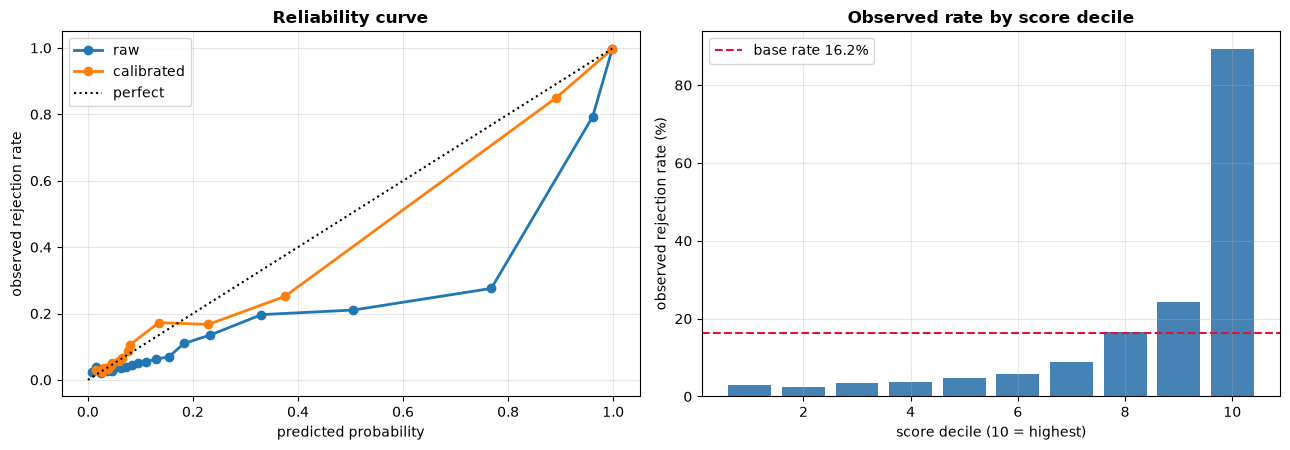

In [20]:
iso = IsotonicRegression(out_of_bounds="clip").fit(val_scores, y_val)
cal_test = iso.predict(test_scores)

print(f"{'':<22}{'Brier':>10}{'mean p̂':>10}{'true rate':>12}{'AP':>10}{'AUC':>10}")
for nm, s in [("raw", test_scores), ("isotonic-calibrated", cal_test)]:
    print(f"{nm:<22}{brier_score_loss(y_test, np.clip(s,0,1)):>10.4f}"
          f"{np.mean(np.clip(s,0,1)):>10.3f}{TEST_BASE_RATE:>12.3f}"
          f"{average_precision_score(y_test, s):>10.4f}{roc_auc_score(y_test, s):>10.4f}")
print("\nAP and AUC are unchanged, as they must be: isotonic regression is monotone,")
print("so it re-labels the scores without reordering a single claim.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for nm, s in [("raw", test_scores), ("calibrated", cal_test)]:
    pt, pp = calibration_curve(y_test, np.clip(s,0,1), n_bins=20, strategy="quantile")
    ax[0].plot(pp, pt, "o-", lw=2, label=nm)
ax[0].plot([0,1],[0,1],"k:",label="perfect")
ax[0].set_xlabel("predicted probability"); ax[0].set_ylabel("observed rejection rate")
ax[0].legend(); ax[0].set_title("Reliability curve", fontweight="bold"); ax[0].grid(alpha=0.3)

dec = pd.qcut(pd.Series(test_scores).rank(method="first"), 10, labels=False)
obs = pd.Series(y_test).groupby(dec).mean()
ax[1].bar(obs.index+1, obs.values*100, color="steelblue")
ax[1].axhline(TEST_BASE_RATE*100, color="crimson", ls="--", label=f"base rate {TEST_BASE_RATE:.1%}")
ax[1].set_xlabel("score decile (10 = highest)"); ax[1].set_ylabel("observed rejection rate (%)")
ax[1].legend(); ax[1].set_title("Observed rate by score decile", fontweight="bold"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §17 — Baselines, ablations, and what the extra tables bought

Two questions worth separating. First, does LightGBM beat the trivial alternatives? Second —
and much more interesting — **was opening thirteen tables worth it?** The ablation removes
each feature block in turn and measures the cost.

In [21]:
base = {"LightGBM (all tables)": test_scores}
rgb = np.random.default_rng(SEED)
base["random"] = rgb.random(len(y_test))

hf_rate = pd.Series(y_train).groupby(df["Hfid"].values[idx_train]).mean()
base["facility rate only"] = pd.Series(hfid_test).map(hf_rate).fillna(y_train.mean()).values

if "FLAG_no_service_lines" in X_test:
    base["no-service-lines rule"] = X_test["FLAG_no_service_lines"].fillna(0).values.astype(float)

cmp_rows = []
for nm, s in base.items():
    o = np.argsort(-s); c = np.cumsum(y_test[o]); k1 = max(int(len(y_test)*0.01),1)
    cmp_rows.append({"model": nm, "ROC_AUC": roc_auc_score(y_test, s),
                     "PR_AUC": average_precision_score(y_test, s),
                     "P@1%": c[k1-1]/k1, "lift@1%": (c[k1-1]/k1)/TEST_BASE_RATE})
bl = pd.DataFrame(cmp_rows).sort_values("PR_AUC", ascending=False)
print(bl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                model  ROC_AUC  PR_AUC   P@1%  lift@1%
LightGBM (all tables)   0.8778  0.7604 1.0000   6.1602
   facility rate only   0.7407  0.5454 0.9624   5.9287
no-service-lines rule   0.7248  0.3315 0.2432   1.4980
               random   0.5003  0.1625 0.1565   0.9643


Full Model (without ClaimCategory) Test AP: 0.7604
-----------------------------------------------------------------
  without policy (TblInsureePolicy + TblPolicy)      test AP 0.6938  (cost: +0.0666)
  without service lines and tariff (TblServices)     test AP 0.7601  (cost: +0.0004)
  without facility and geography (TblHF/Locations)   test AP 0.6918  (cost: +0.0686)
  without diagnosis (TblICDCodes)                    test AP 0.7631  (cost: -0.0026)
  without claim timing and delays                    test AP 0.7765  (cost: -0.0161)
  without claim financials and stay                  test AP 0.7499  (cost: +0.0105)
FEATURE BLOCK ABLATION RESULTS (Which Data Actually Matters):
                           block removed  n_features  test_AP    cost
facility and geography (TblHF/Locations)           6   0.6918  0.0686
   policy (TblInsureePolicy + TblPolicy)           6   0.6938  0.0666
               claim financials and stay           8   0.7499  0.0105
  service lines and tariff (Tbl

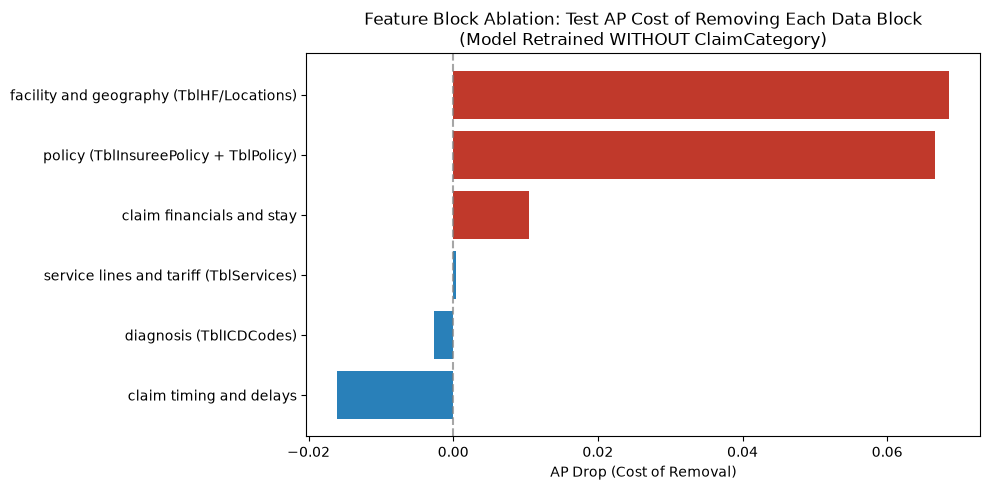

In [23]:
BLOCKS = {
    "policy (TblInsureePolicy + TblPolicy)": [c for c in FEATURES if c.startswith("POL_")
                                              or c in ("FLAG_policy_expired","FLAG_no_policy_found",
                                                       "FLAG_claim_within_30d_of_start")],
    "service lines and tariff (TblServices)": [c for c in FEATURES if c.startswith("SVC_")],
    "patient and household (TblInsuree/Families)": [c for c in FEATURES if c.startswith(("PT_","FAM_"))
                                                  or c == "FLAG_age_missing"],
    "facility and geography (TblHF/Locations)": [c for c in FEATURES if c.startswith(("HF_","GEO_"))
                                               or c == "Hfid"],
    "diagnosis (TblICDCodes)":               [c for c in FEATURES if c.startswith("DX_") or c == "Icdid"],
    "claim timing and delays":               [c for c in FEATURES if c in ("CLM_delay","FLAG_backdated","CLM_month","CLM_dayofweek","FLAG_weekend")],
    "claim financials and stay":             [c for c in FEATURES if c in ("CLM_claimed","CLM_los","FLAG_negative_los","FLAG_round_amount","CLM_cost_per_day","CLM_cost_per_line","CLM_header_line_gap","CLM_vs_tariff_total")],
}
full_ap = average_precision_score(y_test, test_scores)
abl = []
print(f"Full Model (without ClaimCategory) Test AP: {full_ap:.4f}")
print("-" * 65)

for nm, cols in BLOCKS.items():
    cols = [c for c in cols if c in FEATURES]
    if not cols:
        continue
    keep = [c for c in FEATURES if c not in cols]
    cats = [c for c in CAT_FEATURES if c in keep]
    p = dict(BEST_PARAMS)
    dtr = lgb.Dataset(X_train[keep], label=y_train, categorical_feature=cats, free_raw_data=False)
    dva = lgb.Dataset(X_val[keep], label=y_val, reference=dtr,
                      categorical_feature=cats, free_raw_data=False)
    m = lgb.train({**CONFIG["LGB_PARAMS"], **p}, dtr, CONFIG["NUM_BOOST_ROUND"], valid_sets=[dva],
                  callbacks=[lgb.early_stopping(CONFIG["EARLY_STOPPING"], verbose=False)])
    ap = average_precision_score(y_test, m.predict(X_test[keep]))
    cost = full_ap - ap
    abl.append({"block removed": nm, "n_features": len(cols), "test_AP": ap, "cost": cost})
    print(f"  without {nm:<42} test AP {ap:.4f}  (cost: {cost:+.4f})")
    del m, dtr, dva; gc.collect()

ab = pd.DataFrame(abl).sort_values("cost", ascending=False)
print("=" * 65)
print("FEATURE BLOCK ABLATION RESULTS (Which Data Actually Matters):")
print(ab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

top = ab.iloc[0]
print(f"Most valuable block: {top['block removed']} (removing it costs {top['cost']:.4f} AP).")

# Visual bar chart of ablation costs
plt.figure(figsize=(10, 5))
colors = ['#c0392b' if c > 0.01 else '#2980b9' for c in ab['cost']]
plt.barh(ab['block removed'], ab['cost'], color=colors)
plt.xlabel("AP Drop (Cost of Removal)")
plt.title("Feature Block Ablation: Test AP Cost of Removing Each Data Block\n(Model Retrained WITHOUT ClaimCategory)")
plt.gca().invert_yaxis()
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## §18 — SHAP

TreeSHAP gives **exact** Shapley values for a LightGBM model in polynomial time — milliseconds
per claim, no background-sample choice, no run-to-run variance. This is the strongest
explainability story of the four notebooks.

Read the summary plot as a leakage screen before reading it as an explanation. If one feature
dominates everything else, that is leakage rendered visible in a single image.

c:\Users\Samin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.52.0
Exact Shapley values for 20,000 flagged claims

GLOBAL IMPORTANCE (leakage screen)
              feature  mean_abs_shap
         GEO_district        2.01142
   POL_days_to_expiry        1.32309
                 Hfid        1.19705
  CLM_header_line_gap        0.55369
     SVC_tariff_total        0.37113
  FLAG_policy_expired        0.36577
                Icdid        0.34275
POL_days_since_enroll        0.31037
            CLM_month        0.21589
           GEO_region        0.18557
 POL_days_since_start        0.17022
            CLM_delay        0.16954
              CLM_los        0.16265
   SVC_freq_limit_min        0.13693
      SVC_repeat_rate        0.13105
       SVC_asked_mean        0.12826
          SVC_n_lines        0.12592
SVC_tariff_ratio_mean        0.11447
 SVC_tariff_ratio_max        0.10366
     CLM_cost_per_day        0.10231

Top feature carries 23.0% of total attribution.
  [ok] attribution spread across features, as expected without leakage.


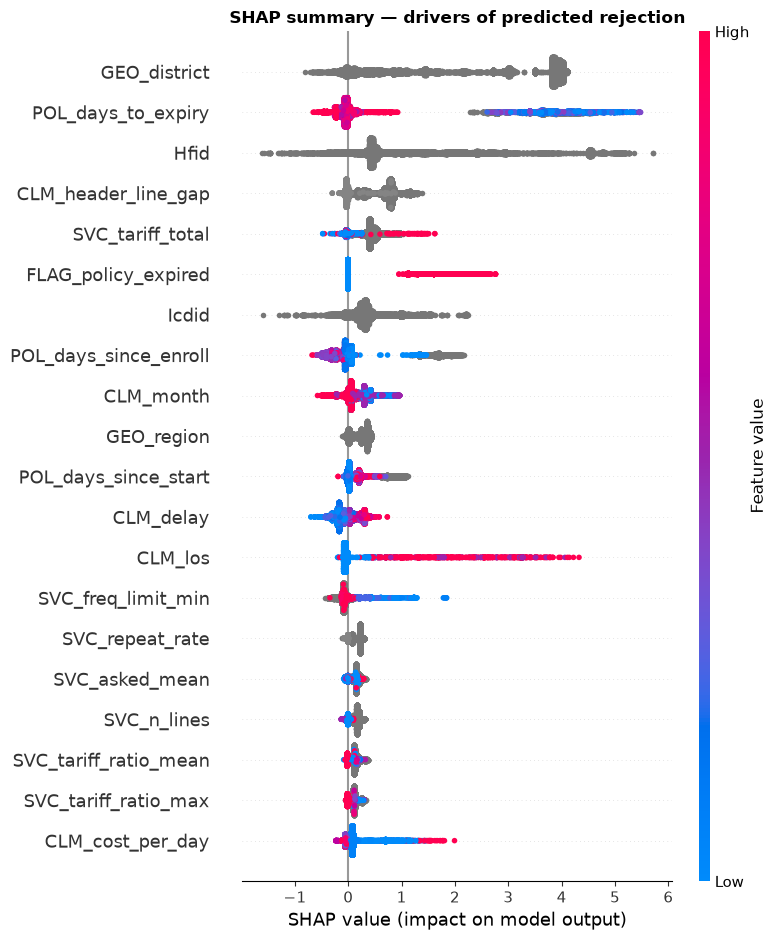

In [24]:
try:
    import shap
    HAS_SHAP = True; print(f"shap {shap.__version__}")
except ImportError:
    HAS_SHAP = False; print("shap not installed.  pip install shap")

if HAS_SHAP:
    rgs = np.random.default_rng(SEED)
    flagged = np.where(preds == 1)[0]
    pool = flagged if len(flagged) >= 500 else np.argsort(-test_scores)[:20000]
    sel = rgs.choice(pool, min(CONFIG["SHAP_SAMPLE"], len(pool)), replace=False)
    X_ex = X_test.iloc[sel]

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_ex)
    sv = np.asarray(sv)
    if sv.ndim == 3:
        sv = sv[..., 1] if sv.shape[-1] == 2 else sv[..., 0]
    print(f"Exact Shapley values for {len(X_ex):,} flagged claims")

    glob = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": np.abs(sv).mean(0)}) \
             .sort_values("mean_abs_shap", ascending=False)
    print("\nGLOBAL IMPORTANCE (leakage screen)")
    print(glob.head(20).to_string(index=False, float_format=lambda v: f"{v:.5f}"))
    share = glob["mean_abs_shap"].iloc[0] / glob["mean_abs_shap"].sum()
    print(f"\nTop feature carries {share:.1%} of total attribution.")
    print("  WARNING: one feature dominates -- verify it is not a leaked field." if share > 0.40
          else "  [ok] attribution spread across features, as expected without leakage.")

    plt.figure()
    shap.summary_plot(sv, X_ex, feature_names=FEATURES, max_display=20, show=False)
    plt.title("SHAP summary — drivers of predicted rejection", fontweight="bold")
    plt.tight_layout(); plt.show()

Highest-scoring flagged claim (test row 20,569)
  ClaimID       : 10472691
  Facility      : 832
  Score         : 1.0000  (100.00nd percentile) | calibrated probability 100.0%
  Actual label  : REJECTED (code 1)

            feature      value   shap
 POL_days_to_expiry  -185.0000 3.0821
               Hfid        832 2.7295
       GEO_district Nkolndongo 1.3421
            CLM_los    30.0000 1.2855
FLAG_policy_expired     1.0000 0.9486
              Icdid       1930 0.5470
   CLM_cost_per_day    20.0000 0.5124
   SVC_tariff_total        NaN 0.4079

Layer 1 — what an auditor should actually see:
  - POL_days_to_expiry = -185.0  (pushes toward rejection)
  - Hfid = 832  (pushes toward rejection)
  - GEO_district = Nkolndongo  (pushes toward rejection)


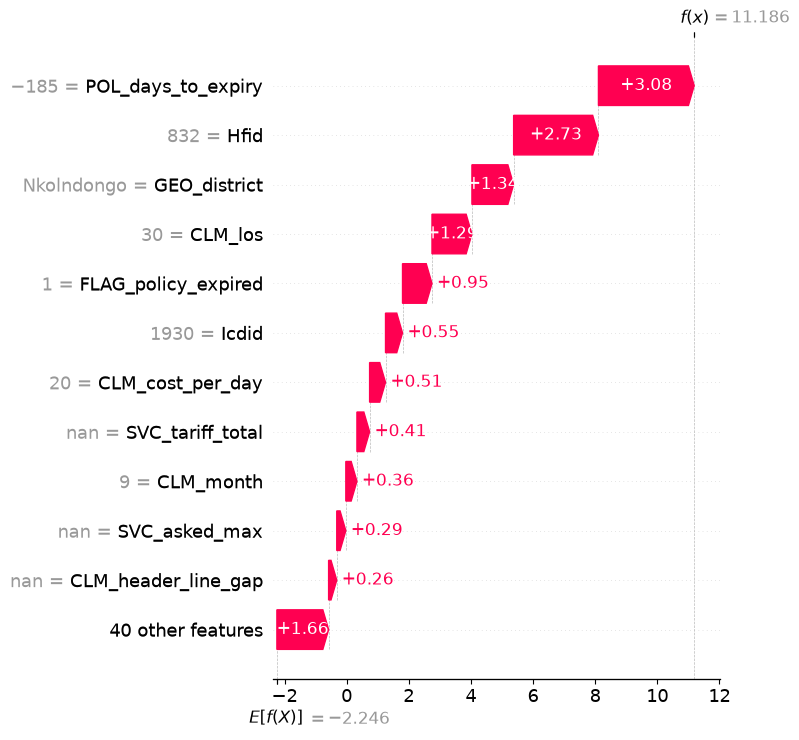

In [25]:
if HAS_SHAP:
    j = int(np.argmax(test_scores[sel])); pos = int(sel[j])
    top = np.argsort(-np.abs(sv[j]))[:8]
    tbl = pd.DataFrame({"feature": [FEATURES[t] for t in top],
                        "value": [X_ex.iloc[j, t] for t in top],
                        "shap": sv[j, top]})
    pct = (test_scores < test_scores[pos]).mean()*100
    print(f"Highest-scoring flagged claim (test row {pos:,})")
    print(f"  ClaimID       : {df['ClaimID'].values[idx_test][pos]}")
    print(f"  Facility      : {hfid_test[pos]}")
    print(f"  Score         : {test_scores[pos]:.4f}  ({pct:.2f}nd percentile)"
          f" | calibrated probability {cal_test[pos]:.1%}")
    print(f"  Actual label  : {'REJECTED' if y_test[pos] else 'accepted'} (code {rej_test[pos]})\n")
    print(tbl.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

    print("\nLayer 1 — what an auditor should actually see:")
    for _, r in tbl[tbl["shap"] > 0].head(3).iterrows():
        print(f"  - {r['feature']} = {r['value']}  (pushes toward rejection)")

    try:
        plt.figure()
        shap.plots.waterfall(shap.Explanation(values=sv[j],
                             base_values=float(np.ravel(explainer.expected_value)[0]),
                             data=X_ex.iloc[j].values, feature_names=FEATURES),
                             max_display=12, show=False)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"\n(waterfall unavailable: {type(e).__name__}) -- the table carries the same information")

## §19 — Per-rejection-code and facility views

The per-code table is the honest bound on this whole exercise: codes near AUC 0.5 are
structurally invisible, and they tell you how much of the target no model can reach.

In [26]:
obs = pd.Series(rej_test[y_test == 1]).value_counts()
print("Rejection codes at claim-header level (test set):")
print(obs.head(15).to_string())
expected = {"3":"policy inactive/expired","4":"demographic mismatch","5":"frequency violation",
            "7":"invalid insurance ID","-1":"manual clinical rejection","2":"not in price list",
            "10":"technical rule","16":"benefit ceiling"}
missing = [c for c in expected if c not in obs.index]
if missing:
    print(f"\nNot present at header level: {missing}  (that taxonomy is service-line level)")

acc = test_scores[y_test == 0]; rows = []
for cv, n in obs.items():
    if n < 200: continue
    m = (rej_test == cv) & (y_test == 1)
    lab = np.concatenate([np.ones(m.sum()), np.zeros(len(acc))])
    rows.append({"code": cv, "meaning": expected.get(str(cv), "?"), "n": int(n),
                 "auc_vs_accepted": roc_auc_score(lab, np.concatenate([test_scores[m], acc])),
                 "detected_at_threshold": float((test_scores[m] > THRESHOLD).mean())})
if rows:
    codes_df = pd.DataFrame(rows).sort_values("auc_vs_accepted", ascending=False)
    print("\nDetectability by rejection code:")
    print(codes_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    weak = codes_df[codes_df["auc_vs_accepted"] < 0.55]
    if len(weak):
        share = weak["n"].sum()/codes_df["n"].sum()
        print(f"\nEssentially undetectable: {weak['code'].tolist()} — {share:.1%} of rejections.")
        print("An upper bound on what ANY model can reach on these features.")

fac = pd.DataFrame({"Hfid": hfid_test, "score": test_scores, "y": y_test, "flagged": preds})
st = fac.groupby("Hfid").agg(claims=("score","size"), mean_score=("score","mean"),
                             flag_rate=("flagged","mean"), rej_rate=("y","mean")).reset_index()
g_mean = float(fac["score"].mean()); g_var = float(st["mean_score"].var())
w_var = float(fac.groupby("Hfid")["score"].var().mean()); k = w_var/max(g_var,1e-12)
st["shrunk"] = (st["claims"]*st["mean_score"] + k*g_mean)/(st["claims"]+k)
elig = st[st["claims"] >= CONFIG["MIN_FACILITY_CLAIMS"]]
print(f"\nFacilities: {len(st):,} total, {len(elig):,} with >= {CONFIG['MIN_FACILITY_CLAIMS']} claims")
print("\nTOP 10 BY SHRUNK MEAN SCORE")
print(elig.sort_values("shrunk", ascending=False).head(10)
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

always = st[(st["rej_rate"] >= 0.99) & (st["claims"] >= 100)]
if len(always):
    print(f"\nFACILITIES WITH ~100% REJECTION ({len(always)} found, "
          f"{int(always['claims'].sum()):,} claims):")
    print(always.sort_values("claims", ascending=False).head(10)
            .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
    print("  These need an administrative fix, not a model. A one-line query finds them.")

Rejection codes at claim-header level (test set):
1     66023
0      1800
21        2

Not present at header level: ['3', '4', '5', '7', '-1', '2', '10', '16']  (that taxonomy is service-line level)

Detectability by rejection code:
code meaning     n  auc_vs_accepted  detected_at_threshold
   0       ?  1800           0.8937                 0.1717
   1       ? 66023           0.8774                 0.5504

Facilities: 915 total, 534 with >= 100 claims

TOP 10 BY SHRUNK MEAN SCORE
 Hfid  claims  mean_score  flag_rate  rej_rate  shrunk
  832    1262      0.9994     1.0000    1.0000  0.9991
  836    2663      0.9991     1.0000    1.0000  0.9990
  857    1462      0.9990     1.0000    1.0000  0.9987
  563    1290      0.9978     1.0000    1.0000  0.9975
 2360    4067      0.9972     1.0000    1.0000  0.9971
 1281     190      0.9987     1.0000    1.0000  0.9963
  804     252      0.9975     1.0000    1.0000  0.9957
 1279   11197      0.9913     0.9997    0.9998  0.9913
  572    1350      

## §20 — Visualisations

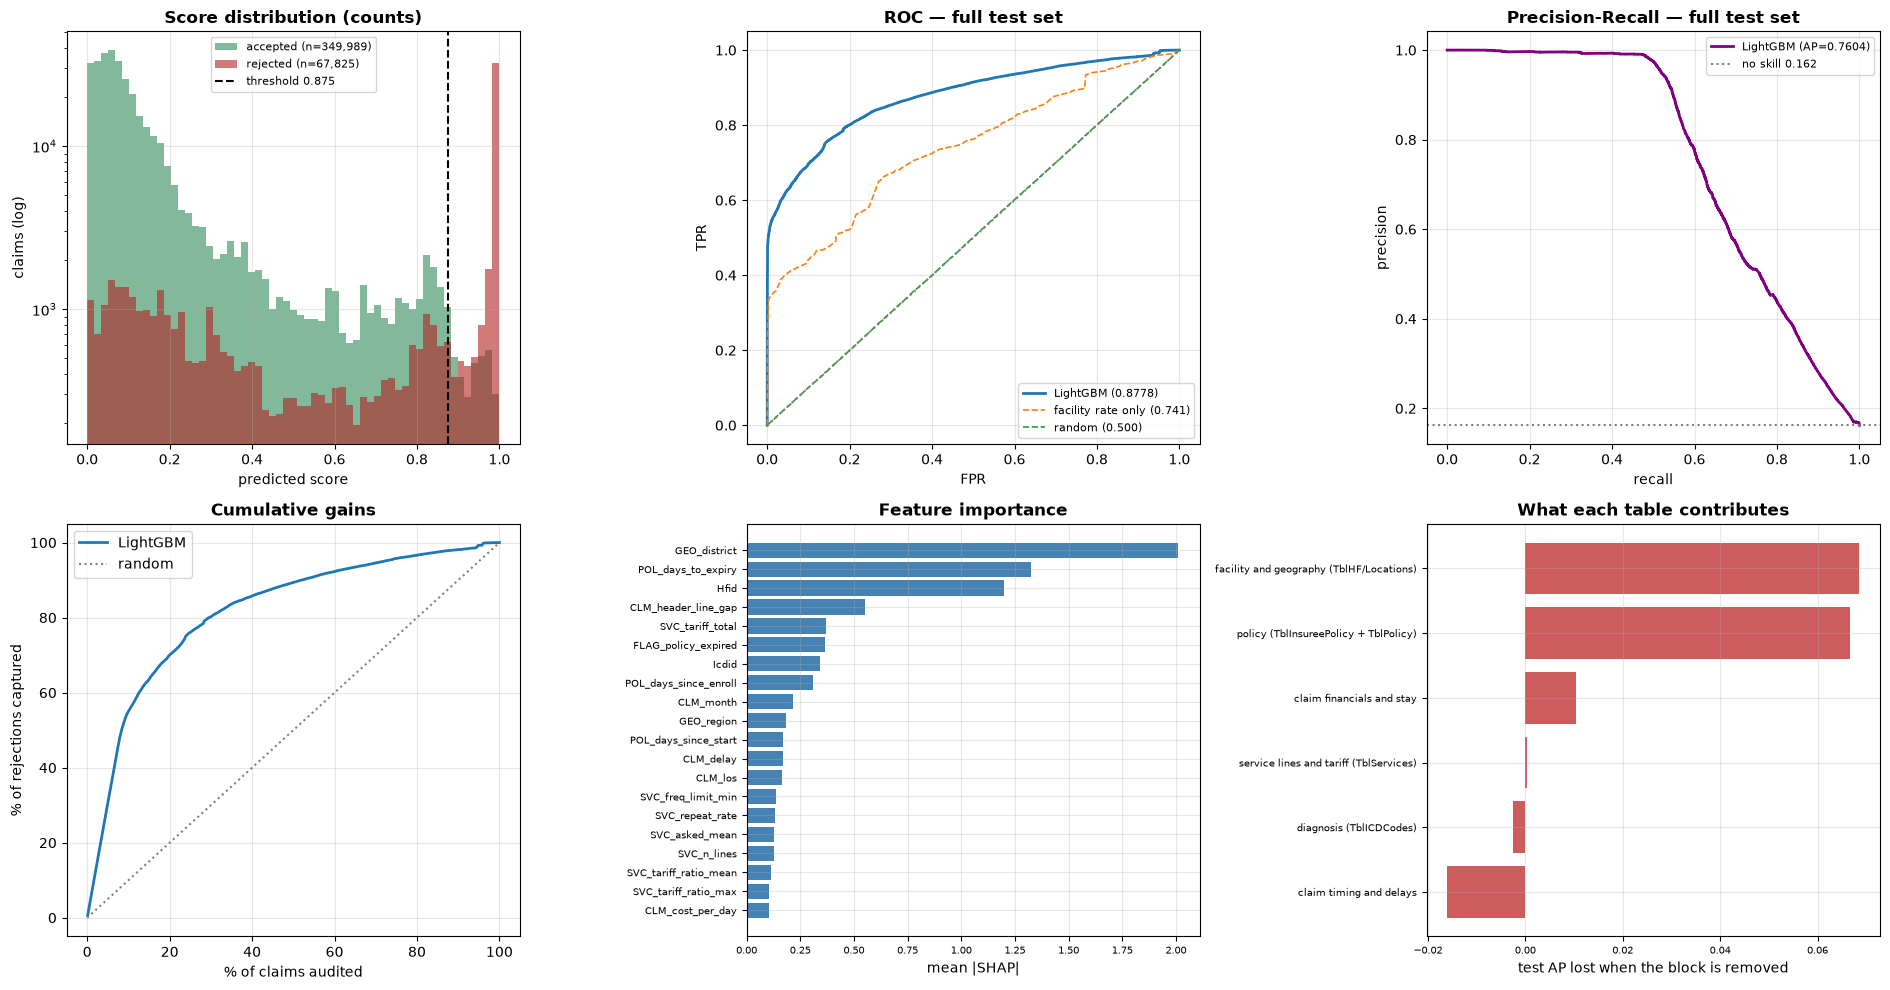

In [27]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

a = ax[0,0]
bins = np.linspace(0, 1, 60)
a.hist(test_scores[y_test==0], bins=bins, color="seagreen", alpha=0.6,
       label=f"accepted (n={int((y_test==0).sum()):,})")
a.hist(test_scores[y_test==1], bins=bins, color="firebrick", alpha=0.6,
       label=f"rejected (n={int((y_test==1).sum()):,})")
a.axvline(THRESHOLD, color="black", ls="--", label=f"threshold {THRESHOLD:.3f}")
a.set_yscale("log"); a.set_xlabel("predicted score"); a.set_ylabel("claims (log)")
a.legend(fontsize=8); a.set_title("Score distribution (counts)", fontweight="bold")

a = ax[0,1]
a.plot(*roc_curve(y_test, test_scores)[:2], lw=2, label=f"LightGBM ({ROC_AUC:.4f})")
for nm in ["facility rate only","random"]:
    if nm in base:
        a.plot(*roc_curve(y_test, base[nm])[:2], lw=1.2, ls="--",
               label=f"{nm} ({roc_auc_score(y_test, base[nm]):.3f})")
a.plot([0,1],[0,1],color="grey",ls=":"); a.set_xlabel("FPR"); a.set_ylabel("TPR")
a.legend(loc="lower right", fontsize=8); a.set_title("ROC — full test set", fontweight="bold")

a = ax[0,2]
pr_, rc_, _ = precision_recall_curve(y_test, test_scores)
a.plot(rc_, pr_, lw=2, color="purple", label=f"LightGBM (AP={PR_AUC:.4f})")
a.axhline(TEST_BASE_RATE, color="grey", ls=":", label=f"no skill {TEST_BASE_RATE:.3f}")
a.set_xlabel("recall"); a.set_ylabel("precision"); a.legend(fontsize=8)
a.set_title("Precision-Recall — full test set", fontweight="bold")

a = ax[1,0]
kk = np.linspace(0.001, 1.0, 400)
gains = [cum[max(int(len(y_test)*k),1)-1]/max(y_test.sum(),1) for k in kk]
a.plot(kk*100, np.array(gains)*100, lw=2, label="LightGBM")
a.plot([0,100],[0,100],color="grey",ls=":",label="random")
a.set_xlabel("% of claims audited"); a.set_ylabel("% of rejections captured")
a.legend(); a.set_title("Cumulative gains", fontweight="bold")

a = ax[1,1]
top20 = glob.head(20)[::-1] if ("glob" in dir()) else imp.head(20)[::-1].rename(
    columns={"gain":"mean_abs_shap"})
a.barh(top20["feature"], top20["mean_abs_shap"], color="steelblue")
a.set_xlabel("mean |SHAP|" if "glob" in dir() else "gain")
a.set_title("Feature importance", fontweight="bold"); a.tick_params(labelsize=7)

a = ax[1,2]
if len(ab):
    a.barh(ab["block removed"][::-1], ab["cost"][::-1], color="indianred")
    a.set_xlabel("test AP lost when the block is removed")
    a.set_title("What each table contributes", fontweight="bold"); a.tick_params(labelsize=7)

for r_ in ax:
    for a_ in r_:
        a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §21 — Export and model card

In [28]:
model.save_model(str(MODEL_DIR / "lightgbm_model.txt"))
joblib.dump({"features": FEATURES, "categorical": CAT_FEATURES,
             "categories": {c: list(X_train[c].cat.categories) for c in CAT_FEATURES}},
            MODEL_DIR / "feature_schema.pkl")
joblib.dump(iso, MODEL_DIR / "isotonic_calibrator.pkl")
np.save(MODEL_DIR / "lgb_test_scores.npy", test_scores)

export = {
    "created": _dt.datetime.now().isoformat(timespec="seconds"),
    "model": "LightGBM (supervised)",
    "target": "ClaimStatus == 1 (claim REJECTION, not fraud)",
    "tables_used": [t for t, on in CONFIG["USE_TABLES"].items() if on and F(t).exists()],
    "n_features": len(FEATURES), "features": FEATURES, "categorical_features": CAT_FEATURES,
    "imbalance_strategy": STRATEGY, "imbalance_ratio": float(IMBALANCE_RATIO),
    "best_params": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                    for k, v in BEST_PARAMS.items()},
    "n_trees": int(model.best_iteration),
    "threshold": THRESHOLD, "threshold_mode": CONFIG["THRESHOLD_MODE"],
    "split": {"mode": CONFIG["SPLIT_MODE"], "train_n": int(len(y_train)),
              "val_n": int(len(y_val)), "test_n": int(len(y_test))},
    "base_rates": {"population": POP_BASE_RATE, "validation": VAL_BASE_RATE, "test": TEST_BASE_RATE},
    "metrics_test": {"roc_auc": float(ROC_AUC), "pr_auc": float(PR_AUC),
                     "precision": float(prec), "recall": float(rec), "f1": float(f1),
                     "alert_rate": float((tp+fp)/len(y_test)),
                     "brier_raw": float(brier_score_loss(y_test, np.clip(test_scores,0,1))),
                     "brier_calibrated": float(brier_score_loss(y_test, np.clip(cal_test,0,1))),
                     "roc_auc_ci95": [float(auc_lo), float(auc_hi)],
                     "pr_auc_ci95": [float(ap_lo), float(ap_hi)]},
    "seed_variance": {"test_ap_mean": float(seed_df["test_AP"].mean()),
                      "test_ap_std": float(seed_df["test_AP"].std()),
                      "n_seeds": int(CONFIG["N_SEEDS"])},
    "ablation": ab.set_index("block removed")["cost"].to_dict() if len(ab) else {},
    "baselines": bl.set_index("model")["PR_AUC"].to_dict(),
    "leakage_controls": {"post_adjudication_features_used": CONFIG["USE_POST_ADJUDICATION_FEATURES"],
                         "deny_list_size": len(DENY),
                         "max_feature_label_corr": float(cs.abs().max()),
                         "max_single_feature_auc": float(au.max()),
                         "point_in_time_policy_join": True},
    "config": {k: v for k, v in CONFIG.items() if k != "LGB_PARAMS"},
}
with open(MODEL_DIR / "lightgbm_config.json", "w") as f:
    json.dump(export, f, indent=2, default=str)

card = f"""# Model Card — Claim Rejection LightGBM

**Created:** {export['created']}

## What this model does
Supervised gradient boosting predicting whether a claim will be rejected, using {len(FEATURES)}
features drawn from {len(export['tables_used'])} openIMIS tables. **The target is rejection, not
fraud.** Most rejections are deterministic eligibility rules the openIMIS engine already enforces
at submission; §19 quantifies how much of the target is reachable.

This model is the **performance ceiling** for the unsupervised methods in the companion
notebooks. It requires labels; they do not.

## Data
- Adjudicated claims only (accepted {CONFIG['ACCEPTED_STATUSES']}, rejected {CONFIG['REJECTED_STATUSES']})
- Temporal split — train {export['split']['train_n']:,} / val {export['split']['val_n']:,} / test {export['split']['test_n']:,}
- Base rates: population {POP_BASE_RATE:.4%}, test {TEST_BASE_RATE:.4%}
- Imbalance {IMBALANCE_RATIO:.1f}:1, handled by: {STRATEGY}
- Policy attributes joined **as-of the service date**, not the latest available row

## Performance (test)
- ROC-AUC {ROC_AUC:.4f} (95% CI {auc_lo:.4f}–{auc_hi:.4f}, clustered by facility)
- PR-AUC {PR_AUC:.4f} vs no-skill {TEST_BASE_RATE:.4f} ({PR_AUC/TEST_BASE_RATE:.2f}x)
- At threshold {THRESHOLD:.6f}: precision {prec:.4f}, recall {rec:.4f}, alert rate {(tp+fp)/len(y_test):.2%}
- Across {CONFIG['N_SEEDS']} seeds: AP {seed_df['test_AP'].mean():.4f} ± {seed_df['test_AP'].std():.4f}
- Brier {brier_score_loss(y_test, np.clip(test_scores,0,1)):.4f} raw → {brier_score_loss(y_test, np.clip(cal_test,0,1)):.4f} calibrated

## Leakage controls
- {len(DENY)} adjudication-time fields on an explicit deny-list
- Max |corr(feature, label)| {cs.abs().max():.4f}; max single-feature AUC {au.max():.4f}
- Category levels fixed on the training window only
- `PolicyStatus` excluded deliberately: it is current state, not state at claim time

## Known limitations
1. Rejection is a weak proxy for fraud.
2. Requires labels, so it cannot score genuinely novel fraud patterns the unsupervised models might.
3. Facility identity is an input; the model partly encodes provider reputation.
4. Uncalibrated scores should not be read as probabilities — use the isotonic calibrator.
5. Not validated prospectively.

## Intended use
Audit-queue triage alongside the rules engine, and as the benchmark ceiling for the
unsupervised models. Advisory only; all decisions human.
"""
(MODEL_DIR / "MODEL_CARD.md").write_text(card, encoding="utf-8")
print(f"Artefacts written to {MODEL_DIR}:")
for p in ["lightgbm_model.txt","feature_schema.pkl","isotonic_calibrator.pkl",
          "lightgbm_config.json","MODEL_CARD.md","lgb_test_scores.npy"]:
    fp = MODEL_DIR / p
    if fp.exists():
        print(f"  {p:<30} {fp.stat().st_size/1024:8.1f} KB")

Artefacts written to ..\model_lightgbm_no_leakage:
  lightgbm_model.txt               2072.1 KB
  feature_schema.pkl                  7.1 KB
  isotonic_calibrator.pkl             2.9 KB
  lightgbm_config.json                5.3 KB
  MODEL_CARD.md                       2.0 KB
  lgb_test_scores.npy              3264.3 KB


## §22 — Four-way comparison

The point of running all four. Save each notebook's test scores and this cell assembles them.

**The gap between LightGBM and the best unsupervised model is the price of not needing labels.**
If it is small, the unsupervised approach is fine and much easier to defend as "fraud
detection" rather than "rule replication". If it is large, labels are carrying most of the
signal — which is itself a finding worth reporting.

Note the comparison is only exact if the other notebooks were run with the same split settings.
This notebook filters implausible dates and uses a wider feature set, so the row counts may
differ; the cell checks and says so rather than comparing incomparable arrays.

In [29]:
paths = {"Autoencoder":      MODEL_DIR.parent / "model" / "ae_test_scores.npy",
         "Isolation Forest": MODEL_DIR.parent / "model_iforest" / "if_test_scores.npy",
         "ECOD":             MODEL_DIR.parent / "model_ecod" / "ecod_test_scores.npy"}
avail = {"LightGBM (supervised)": test_scores}
for nm, p in paths.items():
    if p.exists():
        s = np.load(p)
        if len(s) == len(test_scores):
            avail[nm] = s
        else:
            print(f"{nm}: {len(s):,} scores vs {len(test_scores):,} here -- different split, skipped")
    else:
        print(f"{nm}: not found at {p}")

if len(avail) >= 2:
    from scipy.stats import rankdata, spearmanr
    names = list(avail)
    corr = pd.DataFrame(index=names, columns=names, dtype=float)
    for a_ in names:
        for b_ in names:
            corr.loc[a_, b_] = 1.0 if a_ == b_ else spearmanr(avail[a_], avail[b_]).statistic
    print("\nSpearman rank correlation between detectors:")
    print(corr.to_string(float_format=lambda v: f"{v:.3f}"))

    rows = [{"model": n, "ROC_AUC": roc_auc_score(y_test, s),
             "PR_AUC": average_precision_score(y_test, s)} for n, s in avail.items()]
    ens = np.mean([rankdata(s)/len(s) for s in avail.values()], axis=0)
    rows.append({"model": "Rank ensemble", "ROC_AUC": roc_auc_score(y_test, ens),
                 "PR_AUC": average_precision_score(y_test, ens)})
    res4 = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)
    print("\n" + res4.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    uns = res4[~res4["model"].str.contains("LightGBM|ensemble")]
    if len(uns):
        gap = PR_AUC - uns["PR_AUC"].max()
        print(f"\nSupervised advantage over the best unsupervised model: {gap:+.4f} AP")
        print("  Small. The unsupervised models are capturing most of the available signal,"
              if gap < 0.05 else
              "  Large. Labels carry most of the signal here, so the unsupervised framing")
        print("  and they need no labels -- prefer them if you want a genuinely label-free system."
              if gap < 0.05 else "  substantially understates what is achievable.")
else:
    print("\nRun the companion notebooks to enable the comparison.")

Autoencoder: not found at ..\model\ae_test_scores.npy
Isolation Forest: not found at ..\model_iforest\if_test_scores.npy

Spearman rank correlation between detectors:
                       LightGBM (supervised)   ECOD
LightGBM (supervised)                  1.000 -0.006
ECOD                                  -0.006  1.000

                model  ROC_AUC  PR_AUC
LightGBM (supervised)   0.8778  0.7604
        Rank ensemble   0.7550  0.4125
                 ECOD   0.4897  0.1562

Supervised advantage over the best unsupervised model: +0.6043 AP
  Large. Labels carry most of the signal here, so the unsupervised framing
  substantially understates what is achievable.


---

## Deployment notes

1. Package §3–§6 as a **single versioned transform module used by both training and serving**.
   Thirteen tables means thirteen joins that must behave identically in both paths.
2. The as-of policy join must stay as-of at serving time. Using "the patient's current policy"
   in production while training on the point-in-time version is a silent and severe mismatch.
3. Assert the serving feature frame matches `feature_schema.pkl` in order, dtype and category
   levels. LightGBM will happily score a misaligned frame and return nonsense.
4. Apply the isotonic calibrator before anyone reads a score as a probability.
5. Recalibrate the threshold to real audit capacity; the exported value is a starting point.
6. Retrain on a schedule. The validation-to-test drop measured in §13 is your drift estimate.
7. Track precision against **human adjudication**, not the rejection label.

## What this notebook does not fix

1. **The target.** Rejection is not fraud. §19 bounds how much is reachable. The higher-value
   targets remain the financial-deduction signal (653M XAF across 1.2M *accepted* claims) and
   the tariff breaches now computed in §3 — `SVC_tariff_ratio_max` is sitting in the feature
   set and would make an excellent target in its own right.
2. **The unit of analysis.** Fraud is organised at provider level. The facility view in §19 is
   a hint, not a substitute for proper facility-month profiling.
3. **Prospective validation.** Only a shadow pilot against independent human adjudication
   measures what matters.